In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from collections import Counter
import random
from tqdm import tqdm
from typing import List, Dict, Tuple, Set, Any, Union, Optional

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

MODEL_SAVE_PATH = "../model"
RESULT_SAVE_PATH = "../result"
DATA_PATH = "../data"


Path(MODEL_SAVE_PATH).mkdir(parents=True, exist_ok=True)
Path(RESULT_SAVE_PATH).mkdir(parents=True, exist_ok=True)

Using device: mps


In [2]:
batch_size = 128
embedding_dim = 64
hidden_dim = 128
num_layers = 2
dropout = 0.3
num_epochs = 50
learning_rate = 0.001
weight_decay = 1e-5

In [3]:
class NameDataProcessor:
    """
    名字数据处理器类

    用于加载、处理和编码名字数据，构建字符词汇表，并将名字转换为数字序列。
    支持从多个文件源加载名字数据，包括男性、女性、宠物和其他类别的名字。
    """

    def __init__(self, data_path: str) -> None:
        """
        初始化名字数据处理器

        Args:
            data_path: 数据文件路径
        """
        self.data_path: Path = Path(data_path)
        self.names: List[str] = []
        self.char_to_idx: Dict[str, int] = {}
        self.idx_to_char: Dict[int, str] = {}
        self.vocab_size: int = 0
        self.max_length: int = 0

    def load_names(self) -> List[str]:
        """
        从多个数据文件中加载名字数据

        从以下源加载名字：
        - female.txt: 女性名字
        - male.txt: 男性名字  
        - pet.txt: 宠物名字（提取制表符分隔的第一列）
        - others/目录下的所有.txt文件: 其他类别名字

        对名字进行清理处理：
        - 转换为小写
        - 只保留字母字符
        - 过滤长度小于2的名字
        - 去除重复项

        Returns:
            清理后的唯一名字列表
        """
        all_names: List[str] = []

        female_file: Path = self.data_path / "female.txt"
        if female_file.exists():
            with open(female_file, 'r', encoding='utf-8') as f:
                female_names: List[str] = [line.strip() for line in f if line.strip()]
                all_names.extend(female_names)

        male_file: Path = self.data_path / "male.txt"
        if male_file.exists():
            with open(male_file, 'r', encoding='utf-8') as f:
                male_names: List[str] = [line.strip() for line in f if line.strip()]
                all_names.extend(male_names)

        pet_file: Path = self.data_path / "pet.txt"
        if pet_file.exists():
            with open(pet_file, 'r', encoding='utf-8') as f:
                for line in f:
                    if line.strip() and '\t' in line:
                        pet_name: str = line.split('\t')[0].strip()
                        if pet_name:
                            all_names.append(pet_name)

        others_dir: Path = self.data_path / "others"
        if others_dir.exists():
            for file_path in others_dir.glob("*.txt"):
                with open(file_path, 'r', encoding='utf-8') as f:
                    other_names: List[str] = [line.strip() for line in f if line.strip()]
                    all_names.extend(other_names)

        cleaned_names: List[str] = []
        for name in all_names:
            clean_name: str = ''.join(c.lower() for c in name if c.isalpha())
            if len(clean_name) >= 2:  # At least 2 characters
                cleaned_names.append(clean_name)

        self.names = list(set(cleaned_names))

        return self.names

    def build_vocabulary(self) -> Tuple[Dict[str, int], Dict[int, str]]:
        """
        构建字符词汇表

        从所有名字中提取唯一字符，添加特殊标记，构建字符到索引和索引到字符的映射。
        特殊标记包括：
        - <SOS>: 序列开始标记
        - <EOS>: 序列结束标记  
        - <PAD>: 填充标记

        Returns:
            字符到索引的映射字典和索引到字符的映射字典的元组
        """
        all_chars: Set[str] = set()
        for name in self.names:
            all_chars.update(name)

        special_chars: List[str] = ['<SOS>', '<EOS>', '<PAD>']
        all_chars_list: List[str] = sorted(list(all_chars))
        vocab: List[str] = special_chars + all_chars_list

        self.char_to_idx = {char: idx for idx, char in enumerate(vocab)}
        self.idx_to_char = {idx: char for idx, char in enumerate(vocab)}
        self.vocab_size = len(vocab)

        return self.char_to_idx, self.idx_to_char

    def encode_names(self) -> Tuple[List[List[int]], List[int]]:
        """
        将名字编码为数字序列

        将每个名字转换为字符索引序列，添加开始和结束标记：
        - 在序列开头添加<SOS>标记
        - 将名字中的每个字符转换为对应的索引
        - 在序列结尾添加<EOS>标记

        同时记录每个序列的长度和所有序列的最大长度。

        Returns:
            编码后的名字序列列表和对应长度列表的元组
        """
        encoded_names: List[List[int]] = []
        lengths: List[int] = []

        for name in self.names:
            encoded: List[int] = [self.char_to_idx['<SOS>']]
            encoded.extend([self.char_to_idx[char] for char in name])
            encoded.append(self.char_to_idx['<EOS>'])

            encoded_names.append(encoded)
            lengths.append(len(encoded))

        self.max_length = max(lengths)

        return encoded_names, lengths


processor: NameDataProcessor = NameDataProcessor(DATA_PATH)
names: List[str] = processor.load_names()
char_to_idx, idx_to_char = processor.build_vocabulary()
encoded_names, lengths = processor.encode_names()

In [4]:
names[:10]

['lhommedieu',
 'pelz',
 'rohrs',
 'brena',
 'caria',
 'goupil',
 'capelli',
 'cascio',
 'buch',
 'marjet']

In [5]:
class NameDataset(Dataset):
    """
    名字数据集类

    继承自PyTorch的Dataset类，用于处理名字序列数据。
    将编码后的名字序列进行填充并创建输入-目标序列对，用于序列到序列的模型训练。
    """

    def __init__(self, encoded_names: List[List[int]], max_length: int, pad_idx: int) -> None:
        """
        初始化名字数据集

        Args:
            encoded_names: 编码后的名字序列列表
            max_length: 序列的最大长度
            pad_idx: 填充标记的索引值
        """
        self.encoded_names: List[List[int]] = encoded_names
        self.max_length: int = max_length
        self.pad_idx: int = pad_idx

    def __len__(self) -> int:
        """
        返回数据集的大小

        Returns:
            数据集中名字序列的总数量
        """
        return len(self.encoded_names)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        获取指定索引的数据项

        对名字序列进行填充，并创建用于训练的输入-目标序列对：
        - 将序列填充到最大长度
        - 输入序列为除最后一个字符外的所有字符
        - 目标序列为除第一个字符外的所有字符

        Args:
            idx: 数据项的索引

        Returns:
            输入序列张量和目标序列张量的元组
        """
        encoded_name: List[int] = self.encoded_names[idx]

        padded_name: List[int] = encoded_name + [self.pad_idx] * (self.max_length - len(encoded_name))

        input_seq: torch.Tensor = torch.tensor(padded_name[:-1], dtype=torch.long)
        target_seq: torch.Tensor = torch.tensor(padded_name[1:], dtype=torch.long)

        return input_seq, target_seq


random.shuffle(encoded_names)
train_size: int = int(0.7 * len(encoded_names))
val_size: int = int(0.2 * len(encoded_names))

train_names: List[List[int]] = encoded_names[:train_size]
val_names: List[List[int]] = encoded_names[train_size:train_size + val_size]
test_names: List[List[int]] = encoded_names[train_size + val_size:]

pad_idx: int = char_to_idx['<PAD>']

train_dataset: NameDataset = NameDataset(train_names, processor.max_length, pad_idx)
val_dataset: NameDataset = NameDataset(val_names, processor.max_length, pad_idx)
test_dataset: NameDataset = NameDataset(test_names, processor.max_length, pad_idx)

train_loader: DataLoader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader: DataLoader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader: DataLoader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### Dataset Analysis and Visualization


Total unique names: 64740
Average name length: 6.67
Median name length: 7.0
Min/Max length: 2/17
Total characters in vocabulary: 29


/var/folders/j8/mfdp3rfj6qz1xhlkc79_7qyw0000gn/T/ipykernel_75981/73375940.py:206: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


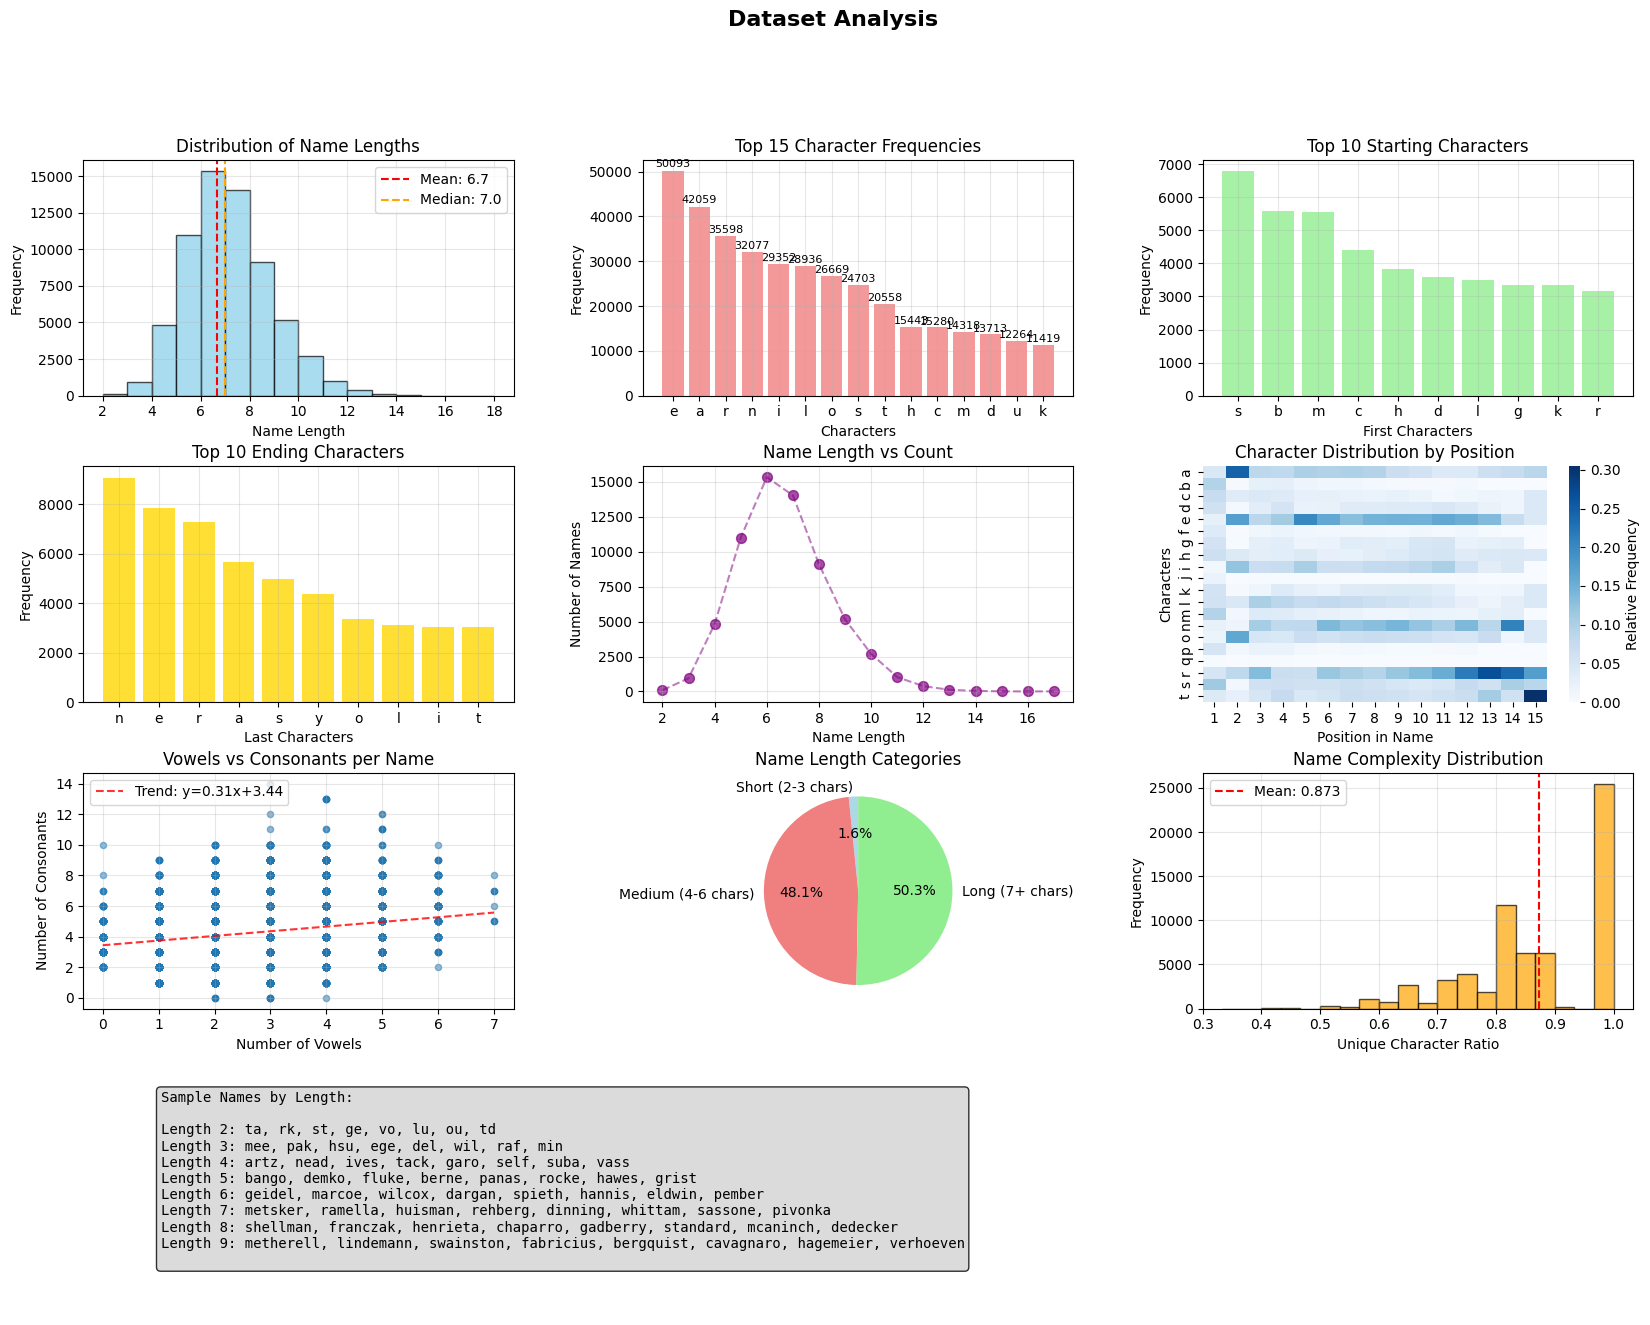


Detailed Statistics:
  Character frequency (top 10): {'e': 50093, 'a': 42059, 'r': 35598, 'n': 32077, 'i': 29352, 'l': 28936, 'o': 26669, 's': 24703, 't': 20558, 'h': 15443}
  Most common starting chars: {'s': 6785, 'b': 5597, 'm': 5560, 'c': 4392, 'h': 3824}
  Most common ending chars: {'n': 9081, 'e': 7864, 'r': 7284, 'a': 5656, 's': 4967}
  Average vowels per name: 2.48
  Average consonants per name: 4.19
  Average complexity ratio: 0.873


In [6]:
def analyze_and_visualize_dataset() -> Dict[str, Any]:
    """
    分析和可视化名字数据集

    对名字数据集进行全面的统计分析和可视化，包括：
    - 名字长度分布统计
    - 字符频率分析
    - 首尾字符分布
    - 位置字符热力图
    - 元音辅音分布
    - 名字复杂度分析
    - 样本展示

    生成包含10个子图的综合分析图表，并保存分析结果到JSON文件。

    Returns:
        包含详细分析结果的字典，包括统计数据、字符频率、长度分布等信息
    """
    total_names: int = len(names)
    name_lengths: List[int] = [len(name) for name in names]

    print(f"Total unique names: {total_names}")
    print(f"Average name length: {np.mean(name_lengths):.2f}")
    print(f"Median name length: {np.median(name_lengths):.1f}")
    print(f"Min/Max length: {min(name_lengths)}/{max(name_lengths)}")
    print(f"Total characters in vocabulary: {processor.vocab_size}")

    fig = plt.figure(figsize=(20, 15))
    gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.hist(name_lengths, bins=range(2, max(name_lengths)+2), alpha=0.7, color='skyblue', edgecolor='black')
    ax1.set_xlabel('Name Length')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Distribution of Name Lengths')
    ax1.grid(True, alpha=0.3)

    ax1.axvline(np.mean(name_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(name_lengths):.1f}')
    ax1.axvline(np.median(name_lengths), color='orange', linestyle='--', label=f'Median: {np.median(name_lengths):.1f}')
    ax1.legend()

    ax2 = fig.add_subplot(gs[0, 1])
    char_counter: Counter = Counter()
    for name in names:
        char_counter.update(name)

    most_common_chars: List[Tuple[str, int]] = char_counter.most_common(15)
    chars: Tuple[str, ...]
    freqs: Tuple[int, ...]
    chars, freqs = zip(*most_common_chars)

    bars = ax2.bar(range(len(chars)), freqs, color='lightcoral', alpha=0.8)
    ax2.set_xlabel('Characters')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Top 15 Character Frequencies')
    ax2.set_xticks(range(len(chars)))
    ax2.set_xticklabels(chars)
    ax2.grid(True, alpha=0.3)

    for bar, freq in zip(bars, freqs):
        height: float = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + height *
                 0.01, f'{freq}', ha='center', va='bottom', fontsize=8)

    ax3 = fig.add_subplot(gs[0, 2])
    first_chars: List[str] = [name[0] for name in names]
    first_char_counter: Counter = Counter(first_chars)
    first_common: List[Tuple[str, int]] = first_char_counter.most_common(10)
    f_chars: Tuple[str, ...]
    f_freqs: Tuple[int, ...]
    f_chars, f_freqs = zip(*first_common)

    ax3.bar(range(len(f_chars)), f_freqs, color='lightgreen', alpha=0.8)
    ax3.set_xlabel('First Characters')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Top 10 Starting Characters')
    ax3.set_xticks(range(len(f_chars)))
    ax3.set_xticklabels(f_chars)
    ax3.grid(True, alpha=0.3)

    ax4 = fig.add_subplot(gs[1, 0])
    last_chars: List[str] = [name[-1] for name in names]
    last_char_counter: Counter = Counter(last_chars)
    last_common: List[Tuple[str, int]] = last_char_counter.most_common(10)
    l_chars: Tuple[str, ...]
    l_freqs: Tuple[int, ...]
    l_chars, l_freqs = zip(*last_common)

    ax4.bar(range(len(l_chars)), l_freqs, color='gold', alpha=0.8)
    ax4.set_xlabel('Last Characters')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Top 10 Ending Characters')
    ax4.set_xticks(range(len(l_chars)))
    ax4.set_xticklabels(l_chars)
    ax4.grid(True, alpha=0.3)

    ax5 = fig.add_subplot(gs[1, 1])
    length_freq: Counter = Counter(name_lengths)
    lengths: Tuple[int, ...]
    counts: Tuple[int, ...]
    lengths, counts = zip(*sorted(length_freq.items()))

    ax5.scatter(lengths, counts, alpha=0.7, s=50, c='purple')
    ax5.plot(lengths, counts, '--', alpha=0.5, color='purple')
    ax5.set_xlabel('Name Length')
    ax5.set_ylabel('Number of Names')
    ax5.set_title('Name Length vs Count')
    ax5.grid(True, alpha=0.3)

    ax6 = fig.add_subplot(gs[1, 2])
    max_len: int = min(15, max(name_lengths))
    unique_chars: List[str] = sorted(list(set(''.join(names))))[:20]

    position_char_matrix: np.ndarray = np.zeros((len(unique_chars), max_len))

    for name in names:
        for pos, char in enumerate(name[:max_len]):
            if char in unique_chars:
                char_idx: int = unique_chars.index(char)
                position_char_matrix[char_idx, pos] += 1

    for pos in range(max_len):
        total_at_pos: float = position_char_matrix[:, pos].sum()
        if total_at_pos > 0:
            position_char_matrix[:, pos] /= total_at_pos

    sns.heatmap(position_char_matrix,
                xticklabels=range(1, max_len+1),
                yticklabels=unique_chars,
                cmap='Blues',
                cbar_kws={'label': 'Relative Frequency'},
                ax=ax6)
    ax6.set_title('Character Distribution by Position')
    ax6.set_xlabel('Position in Name')
    ax6.set_ylabel('Characters')

    ax7 = fig.add_subplot(gs[2, 0])
    vowels: Set[str] = set('aeiou')
    vowel_counts: List[int] = []
    consonant_counts: List[int] = []

    for name in names:
        v_count: int = sum(1 for c in name if c in vowels)
        c_count: int = len(name) - v_count
        vowel_counts.append(v_count)
        consonant_counts.append(c_count)

    ax7.scatter(vowel_counts, consonant_counts, alpha=0.5, s=20)
    ax7.set_xlabel('Number of Vowels')
    ax7.set_ylabel('Number of Consonants')
    ax7.set_title('Vowels vs Consonants per Name')
    ax7.grid(True, alpha=0.3)

    z: np.ndarray = np.polyfit(vowel_counts, consonant_counts, 1)
    p: np.poly1d = np.poly1d(z)
    ax7.plot(sorted(vowel_counts), p(sorted(vowel_counts)), "r--", alpha=0.8, label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')
    ax7.legend()

    ax8 = fig.add_subplot(gs[2, 1])

    pattern_names: Dict[str, List[str]] = {
        'Short (2-3 chars)': [name for name in names if len(name) <= 3],
        'Medium (4-6 chars)': [name for name in names if 4 <= len(name) <= 6],
        'Long (7+ chars)': [name for name in names if len(name) >= 7],
    }

    pattern_counts: List[int] = [len(pattern_names[key]) for key in pattern_names.keys()]
    colors: List[str] = ['lightblue', 'lightcoral', 'lightgreen']

    wedges, texts, autotexts = ax8.pie(pattern_counts, labels=pattern_names.keys(),
                                       autopct='%1.1f%%', colors=colors, startangle=90)
    ax8.set_title('Name Length Categories')

    ax9 = fig.add_subplot(gs[2, 2])
    complexity_ratios: List[float] = [len(set(name))/len(name) for name in names]

    ax9.hist(complexity_ratios, bins=20, alpha=0.7, color='orange', edgecolor='black')
    ax9.set_xlabel('Unique Character Ratio')
    ax9.set_ylabel('Frequency')
    ax9.set_title('Name Complexity Distribution')
    ax9.axvline(np.mean(complexity_ratios), color='red', linestyle='--',
                label=f'Mean: {np.mean(complexity_ratios):.3f}')
    ax9.legend()
    ax9.grid(True, alpha=0.3)

    ax10 = fig.add_subplot(gs[3, :])
    ax10.axis('off')

    sample_text: str = "Sample Names by Length:\n\n"
    length_groups: Dict[int, List[str]] = {}
    for name in names:
        length: int = len(name)
        if length not in length_groups:
            length_groups[length] = []
        length_groups[length].append(name)

    for length in sorted(length_groups.keys())[:8]:
        samples: List[str] = random.sample(length_groups[length], min(8, len(length_groups[length])))
        sample_text += f"Length {length}: {', '.join(samples)}\n"

    ax10.text(0.05, 0.95, sample_text, transform=ax10.transAxes, fontsize=10,
              verticalalignment='top', fontfamily='monospace',
              bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

    plt.suptitle('Dataset Analysis', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig(f"{RESULT_SAVE_PATH}/dataset_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("\nDetailed Statistics:")
    print(f"  Character frequency (top 10): {dict(most_common_chars[:10])}")
    print(f"  Most common starting chars: {dict(first_common[:5])}")
    print(f"  Most common ending chars: {dict(last_common[:5])}")
    print(f"  Average vowels per name: {np.mean(vowel_counts):.2f}")
    print(f"  Average consonants per name: {np.mean(consonant_counts):.2f}")
    print(f"  Average complexity ratio: {np.mean(complexity_ratios):.3f}")

    analysis_results: Dict[str, Any] = {
        'total_names': total_names,
        'length_stats': {
            'mean': float(np.mean(name_lengths)),
            'median': float(np.median(name_lengths)),
            'min': int(min(name_lengths)),
            'max': int(max(name_lengths)),
            'std': float(np.std(name_lengths))
        },
        'character_stats': {
            'total_unique_chars': len(set(''.join(names))),
            'most_common_chars': dict(most_common_chars[:20]),
            'most_common_first_chars': dict(first_common[:10]),
            'most_common_last_chars': dict(last_common[:10])
        },
        'complexity_stats': {
            'avg_vowels_per_name': float(np.mean(vowel_counts)),
            'avg_consonants_per_name': float(np.mean(consonant_counts)),
            'avg_complexity_ratio': float(np.mean(complexity_ratios))
        },
        'length_distribution': dict(Counter(name_lengths)),
        'sample_names_by_length': {str(k): v[:10] for k, v in length_groups.items()}
    }

    with open(f"{RESULT_SAVE_PATH}/dataset_analysis.json", 'w') as f:
        json.dump(analysis_results, f, indent=2)

    return analysis_results


dataset_analysis: Dict[str, Any] = analyze_and_visualize_dataset()

In [7]:
class NameGeneratorRNN(nn.Module):
    """
    基于LSTM的名字生成器神经网络模型

    使用LSTM架构构建的序列到序列模型，用于生成名字。
    模型包含嵌入层、多层LSTM和全连接输出层，支持字符级别的序列生成。
    """

    def __init__(self, vocab_size: int, embedding_dim: int, hidden_dim: int,
                 num_layers: int = 3, dropout: float = 0.2) -> None:
        """
        初始化名字生成器RNN模型

        Args:
            vocab_size: 词汇表大小，包含所有字符和特殊标记的总数
            embedding_dim: 嵌入层维度，字符向量的维度大小
            hidden_dim: LSTM隐藏层维度
            num_layers: LSTM层数，默认为3层
            dropout: Dropout比率，用于防止过拟合，默认为0.2
        """
        super(NameGeneratorRNN, self).__init__()
        self.vocab_size: int = vocab_size
        self.embedding_dim: int = embedding_dim
        self.hidden_dim: int = hidden_dim
        self.num_layers: int = num_layers

        # Embedding layer
        self.embedding: nn.Embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        # LSTM layer
        self.lstm: nn.LSTM = nn.LSTM(embedding_dim, hidden_dim, num_layers,
                                     dropout=dropout, batch_first=True)

        # Output layer
        self.fc: nn.Linear = nn.Linear(hidden_dim, vocab_size)
        self.dropout: nn.Dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, hidden: Optional[Tuple[torch.Tensor, torch.Tensor]] = None) -> Tuple[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        """
        模型前向传播

        将输入序列通过嵌入层、LSTM层和输出层，生成下一个字符的概率分布。

        Args:
            x: 输入张量，形状为 (batch_size, seq_len)，包含字符索引序列
            hidden: LSTM隐藏状态和细胞状态的元组，可选参数
                   如果为None，则使用零初始化的隐藏状态

        Returns:
            输出张量和隐藏状态的元组：
            - output: 形状为 (batch_size, seq_len, vocab_size) 的输出张量
            - hidden: 更新后的隐藏状态和细胞状态元组
        """
        # x shape: (batch_size, seq_len)
        embedded: torch.Tensor = self.embedding(x)  # (batch_size, seq_len, embedding_dim)

        lstm_out: torch.Tensor
        hidden: Tuple[torch.Tensor, torch.Tensor]
        lstm_out, hidden = self.lstm(embedded, hidden)  # (batch_size, seq_len, hidden_dim)

        lstm_out = self.dropout(lstm_out)

        output: torch.Tensor = self.fc(lstm_out)  # (batch_size, seq_len, vocab_size)

        return output, hidden

    def init_hidden(self, batch_size: int, device: torch.device) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        初始化LSTM的隐藏状态和细胞状态

        创建零初始化的隐藏状态和细胞状态张量，用于LSTM的初始输入。

        Args:
            batch_size: 批次大小
            device: 计算设备（CPU或GPU）

        Returns:
            隐藏状态和细胞状态的元组，两个张量的形状都是 (num_layers, batch_size, hidden_dim)
        """
        hidden: torch.Tensor = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device)
        cell: torch.Tensor = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device)
        return (hidden, cell)


model: NameGeneratorRNN = NameGeneratorRNN(
    vocab_size=processor.vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    dropout=dropout
).to(device)

In [8]:
model

NameGeneratorRNN(
  (embedding): Embedding(29, 64, padding_idx=2)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=29, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

In [9]:
def train_epoch(model: nn.Module, train_loader: DataLoader, criterion: nn.Module,
                optimizer: torch.optim.Optimizer, device: torch.device,
                epoch: int, num_epochs: int) -> Tuple[float, float]:
    """
    执行单个训练轮次

    在一个epoch中训练模型，包括前向传播、损失计算、反向传播和参数更新。
    使用梯度裁剪防止梯度爆炸，通过掩码忽略填充标记的损失计算。
    实时显示训练进度和指标，包括损失、准确率、困惑度和学习率。

    Args:
        model: 要训练的神经网络模型
        train_loader: 训练数据加载器
        criterion: 损失函数
        optimizer: 优化器
        device: 计算设备（CPU或GPU）
        epoch: 当前轮次编号（从0开始）
        num_epochs: 总训练轮次数

    Returns:
        平均损失和准确率的元组
    """
    model.train()
    total_loss: float = 0
    total_correct: int = 0
    total_tokens: int = 0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1:2d}/{num_epochs} [Train]')

    for batch_idx, (input_seq, target_seq) in enumerate(pbar):
        input_seq = input_seq.to(device)
        target_seq = target_seq.to(device)

        optimizer.zero_grad()

        output, _ = model(input_seq)

        output = output.view(-1, model.vocab_size)
        target = target_seq.view(-1)

        mask = target != pad_idx
        output_masked = output[mask]
        target_masked = target[mask]

        loss = criterion(output_masked, target_masked)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        pred = output_masked.argmax(dim=-1)
        correct = (pred == target_masked).sum().item()

        total_loss += loss.item()
        total_correct += correct
        total_tokens += target_masked.size(0)

        current_loss: float = total_loss / (batch_idx + 1)
        current_acc: float = total_correct / total_tokens if total_tokens > 0 else 0
        current_ppl: float = calculate_perplexity(current_loss)
        current_lr: float = optimizer.param_groups[0]['lr']

        pbar.set_postfix({
            'T_Loss': f'{current_loss:.4f}',
            'T_Acc': f'{current_acc:.4f}',
            'T_PPL': f'{current_ppl:.2f}',
            'LR': f'{current_lr:.1e}',
        })

    avg_loss: float = total_loss / len(train_loader)
    accuracy: float = total_correct / total_tokens

    return avg_loss, accuracy


def evaluate(model: nn.Module, data_loader: DataLoader, criterion: nn.Module,
             device: torch.device, mode: str = 'Val') -> Tuple[float, float]:
    """
    评估模型性能

    在验证集或测试集上评估模型性能，不进行梯度计算和参数更新。
    计算平均损失、准确率和困惑度，实时显示评估进度。
    支持验证模式和测试模式，通过mode参数区分。

    Args:
        model: 要评估的神经网络模型
        data_loader: 数据加载器（验证集或测试集）
        criterion: 损失函数
        device: 计算设备（CPU或GPU）
        mode: 评估模式，默认为'Val'（验证），也可设置为'Test'（测试）

    Returns:
        平均损失和准确率的元组
    """
    model.eval()
    total_loss: float = 0
    total_correct: int = 0
    total_tokens: int = 0

    pbar = tqdm(data_loader, desc=f'[{mode:4s}]')

    with torch.no_grad():
        for batch_idx, (input_seq, target_seq) in enumerate(pbar):
            input_seq = input_seq.to(device)
            target_seq = target_seq.to(device)

            output, _ = model(input_seq)

            output = output.view(-1, model.vocab_size)
            target = target_seq.view(-1)

            mask = target != pad_idx
            output_masked = output[mask]
            target_masked = target[mask]

            loss = criterion(output_masked, target_masked)

            pred = output_masked.argmax(dim=-1)
            correct = (pred == target_masked).sum().item()

            total_loss += loss.item()
            total_correct += correct
            total_tokens += target_masked.size(0)

            # Update progress bar with validation metrics
            current_loss: float = total_loss / (batch_idx + 1)
            current_acc: float = total_correct / total_tokens if total_tokens > 0 else 0
            current_ppl: float = calculate_perplexity(current_loss)

            pbar.set_postfix({
                'V_Loss': f'{current_loss:.4f}',
                'V_Acc': f'{current_acc:.4f}',
                'V_PPL': f'{current_ppl:.2f}',
            })

    avg_loss: float = total_loss / len(data_loader)
    accuracy: float = total_correct / total_tokens

    return avg_loss, accuracy


def calculate_perplexity(loss: float) -> float:
    """
    计算困惑度

    基于损失值计算困惑度（perplexity），困惑度是衡量语言模型性能的重要指标。
    困惑度越小表示模型性能越好，计算公式为 exp(loss)。

    Args:
        loss: 平均损失值

    Returns:
        困惑度值
    """
    return torch.exp(torch.tensor(loss)).item()

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_perplexities = []
val_perplexities = []
learning_rate_history = []

best_val_loss = float('inf')
patience = 10
early_stop_counter = 0

for epoch in range(num_epochs):
    current_lr = optimizer.param_groups[0]['lr']
    learning_rate_history.append(current_lr)

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, epoch, num_epochs)

    val_loss, val_acc = evaluate(model, val_loader, criterion, device, 'Val')

    train_perplexity = calculate_perplexity(train_loss)
    val_perplexity = calculate_perplexity(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    train_perplexities.append(train_perplexity)
    val_perplexities.append(val_perplexity)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'epoch': epoch,
            'char_to_idx': char_to_idx,
            'idx_to_char': idx_to_char,
            'model_config': {
                'vocab_size': processor.vocab_size,
                'embedding_dim': embedding_dim,
                'hidden_dim': hidden_dim,
                'num_layers': num_layers,
                'dropout': dropout
            }
        }, f"{MODEL_SAVE_PATH}/best_model.pth")
    else:
        early_stop_counter += 1

    if early_stop_counter >= patience:
        print(f'Early stopping triggered after {patience} epochs without improvement')
        break

print(f"Training completed! Best validation loss: {best_val_loss:.4f}")

[Val ]: 100%|██████████| 102/102 [00:00<00:00, 135.32it/s, V_Loss=2.1495, V_Acc=0.3298, V_PPL=8.58]

Training completed! Best validation loss: 2.1487


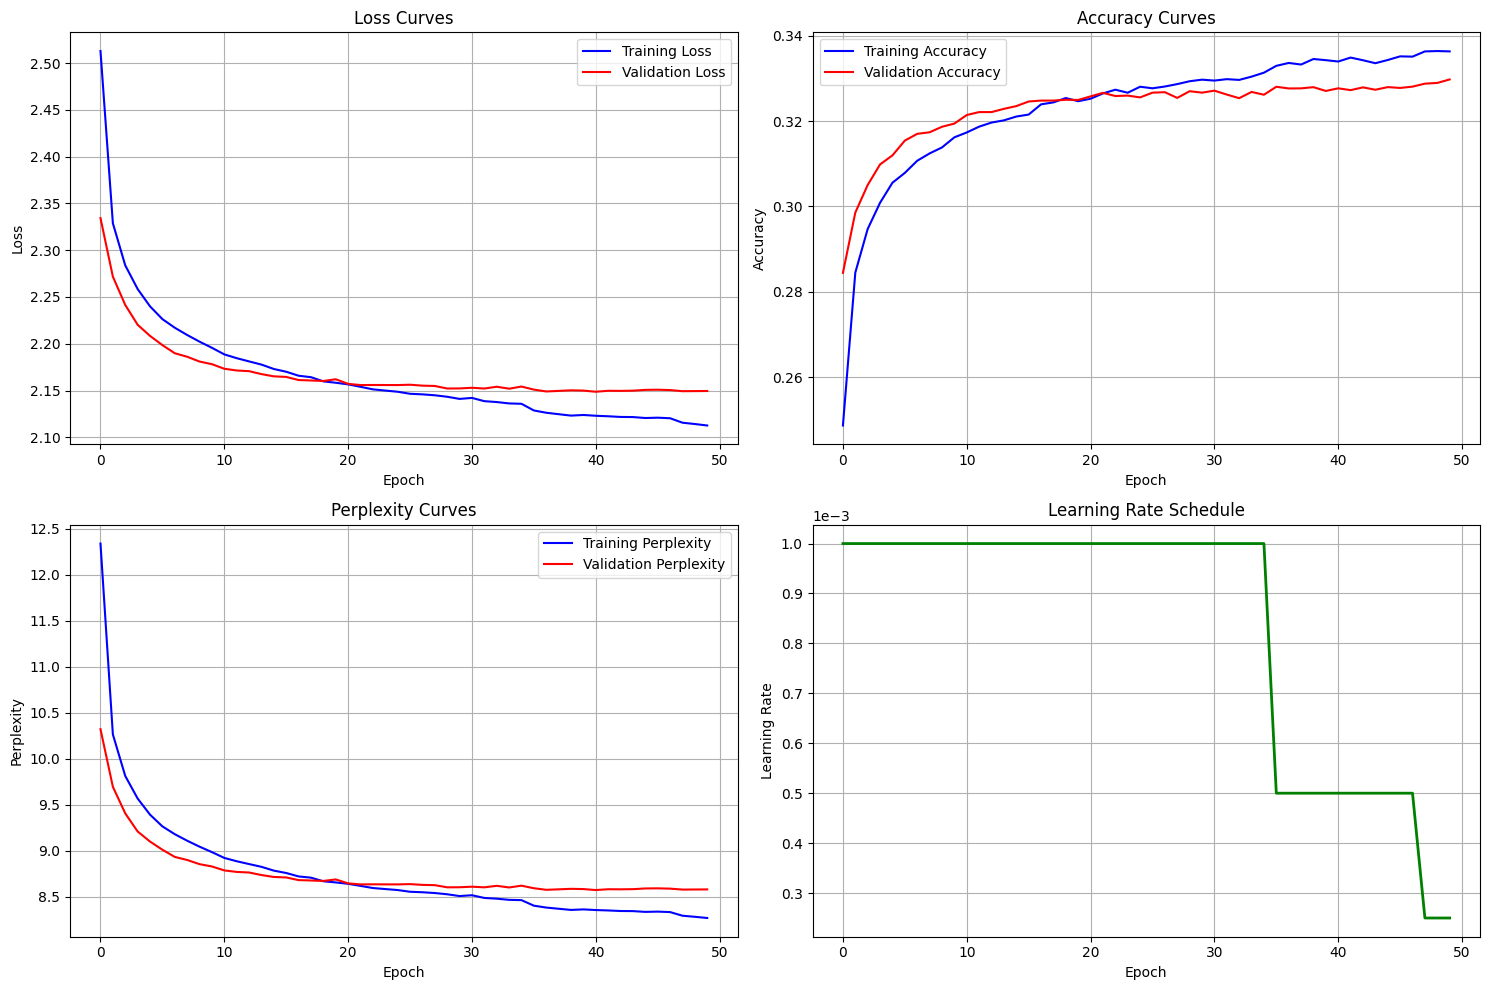

[Test]: 100%|██████████| 51/51 [00:00<00:00, 149.81it/s, V_Loss=2.1390, V_Acc=0.3296, V_PPL=8.49]

Test Results:
  Loss: 2.1390
  Accuracy: 0.3296
  Perplexity: 8.49


In [11]:
def plot_training_curves() -> None:
    """
    绘制训练过程的各项指标曲线

    创建一个2x2的子图布局，显示训练过程中的关键指标变化：
    - 损失曲线：训练损失和验证损失的对比
    - 准确率曲线：训练准确率和验证准确率的对比  
    - 困惑度曲线：训练困惑度和验证困惑度的对比
    - 学习率调度：学习率随epoch的变化情况

    所有曲线图都包含网格线和图例，便于分析模型训练效果。
    图表保存为高分辨率PNG文件并显示。
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    axes[0, 0].plot(train_losses, label='Training Loss', color='blue')
    axes[0, 0].plot(val_losses, label='Validation Loss', color='red')
    axes[0, 0].set_title('Loss Curves')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot(train_accuracies, label='Training Accuracy', color='blue')
    axes[0, 1].plot(val_accuracies, label='Validation Accuracy', color='red')
    axes[0, 1].set_title('Accuracy Curves')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    axes[1, 0].plot(train_perplexities, label='Training Perplexity', color='blue')
    axes[1, 0].plot(val_perplexities, label='Validation Perplexity', color='red')
    axes[1, 0].set_title('Perplexity Curves')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Perplexity')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    if len(learning_rate_history) > 0:
        axes[1, 1].plot(learning_rate_history, color='green', linewidth=2)
        axes[1, 1].set_title('Learning Rate Schedule')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Learning Rate')
        axes[1, 1].grid(True)
        axes[1, 1].ticklabel_format(style='scientific', axis='y', scilimits=(0, 0))
    else:
        axes[1, 1].text(0.5, 0.5, 'No LR history recorded',
                        transform=axes[1, 1].transAxes, ha='center', va='center')
        axes[1, 1].set_title('Learning Rate Schedule')

    plt.tight_layout()
    plt.savefig(f"{RESULT_SAVE_PATH}/training_curves.png", dpi=300, bbox_inches='tight')
    plt.show()


plot_training_curves()

test_loss, test_acc = evaluate(model, test_loader, criterion, device, 'Test')
test_perplexity = calculate_perplexity(test_loss)

print(f"Test Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Perplexity: {test_perplexity:.2f}")

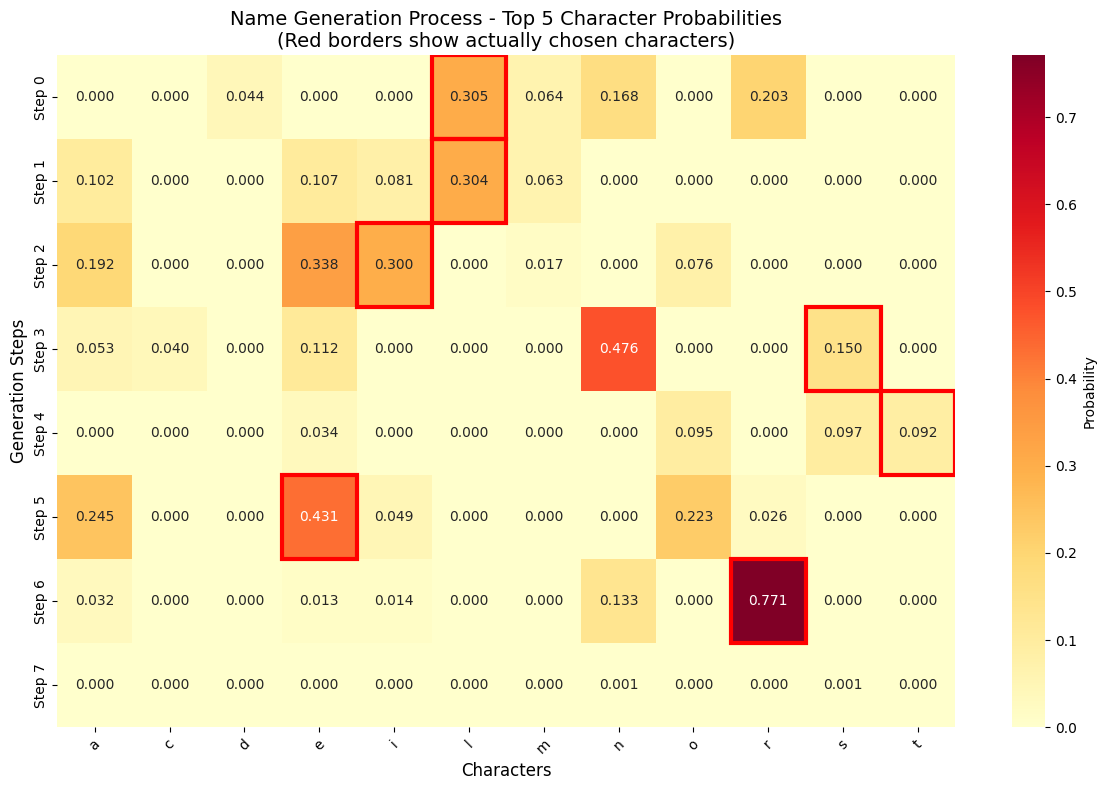

In [ ]:
def generate_name(model: torch.nn.Module, start_chars: str = "", max_length: int = 20,
                  temperature: float = 1.0, top_k: int = 5) -> Tuple[str, List[Dict[str, Any]]]:
    """
    使用训练好的模型生成名字

    基于给定的起始字符（可选）生成新的名字，支持多种采样策略。
    使用Top-K采样和温度调节来控制生成的随机性和质量。
    记录生成过程中每一步的详细信息，包括候选字符、概率分布和选择过程。

    Args:
        model: 训练好的名字生成模型
        start_chars: 起始字符串，为空则从SOS标记开始生成，默认为空字符串
        max_length: 生成名字的最大长度，默认为20个字符
        temperature: 温度参数，控制生成的随机性。0为贪心搜索，>1增加随机性，默认为1.0
        top_k: Top-K采样的K值，只考虑概率最高的K个字符，默认为5

    Returns:
        生成的名字字符串和包含生成过程详细信息的列表的元组
    """
    model.eval()

    with torch.no_grad():
        if start_chars:
            input_seq: List[int] = [char_to_idx['<SOS>']] + [char_to_idx[c.lower()]
                                                             for c in start_chars if c.lower() in char_to_idx]
        else:
            input_seq: List[int] = [char_to_idx['<SOS>']]

        generated_name: str = start_chars.lower()
        generation_info: List[Dict[str, Any]] = []

        for i in range(max_length):
            input_tensor: torch.Tensor = torch.tensor([input_seq], dtype=torch.long).to(device)

            output, _ = model(input_tensor)
            last_output: torch.Tensor = output[0, -1, :]

            last_output = last_output / temperature

            probs: torch.Tensor = F.softmax(last_output, dim=-1)
            top_k_probs: torch.Tensor
            top_k_indices: torch.Tensor
            top_k_probs, top_k_indices = torch.topk(probs, top_k)

            if temperature == 0:
                next_char_idx: int = top_k_indices[0].item()
                chosen_prob: float = top_k_probs[0].item()
                sampling_method: str = "greedy"
            else:
                sampled_idx: int = torch.multinomial(top_k_probs, 1).item()
                next_char_idx: int = top_k_indices[sampled_idx].item()
                chosen_prob: float = top_k_probs[sampled_idx].item()
                sampling_method: str = f"temp_{temperature}"

            next_char: str = idx_to_char[next_char_idx]

            step_info: Dict[str, Any] = {
                'step': i,
                'current_sequence': generated_name,
                'top_k_chars': [idx_to_char[idx.item()] for idx in top_k_indices],
                'top_k_probs': top_k_probs.cpu().numpy(),
                'chosen_char': next_char,
                'chosen_prob': chosen_prob,
                'chosen_rank': sampled_idx if temperature > 0 else 0,
                'sampling_method': sampling_method,
                'temperature': temperature
            }
            generation_info.append(step_info)

            if next_char == '<EOS>':
                break

            if next_char not in ['<SOS>', '<PAD>']:
                generated_name += next_char
                input_seq.append(next_char_idx)

        return generated_name, generation_info


def visualize_generation_process(generation_info: List[Dict[str, Any]], save_path: Optional[str] = None) -> None:
    """
    可视化名字生成过程

    创建热力图显示生成过程中每一步的字符概率分布。
    使用颜色深浅表示概率大小，红色边框标出实际选择的字符。
    帮助理解模型在生成过程中的决策过程和概率分布变化。

    Args:
        generation_info: 包含生成过程详细信息的列表，由generate_name函数返回
        save_path: 图片保存路径，可选参数。如果提供则保存图片到指定路径
    """
    if not generation_info:
        return

    steps: int = len(generation_info)
    fig, ax = plt.subplots(figsize=(12, 8))

    chars_all: List[str] = []
    probs_all: List[float] = []

    for info in generation_info:
        chars_all.extend(info['top_k_chars'])
        probs_all.extend(info['top_k_probs'])

    unique_chars: List[str] = list(set(chars_all))
    unique_chars = [c for c in unique_chars if c not in ['<SOS>', '<EOS>', '<PAD>']]
    unique_chars = sorted(unique_chars)

    heatmap_data: np.ndarray = np.zeros((steps, len(unique_chars)))

    for i, info in enumerate(generation_info):
        for j, char in enumerate(unique_chars):
            if char in info['top_k_chars']:
                char_idx: int = info['top_k_chars'].index(char)
                heatmap_data[i, j] = info['top_k_probs'][char_idx]

    sns.heatmap(heatmap_data,
                xticklabels=unique_chars,
                yticklabels=[f"Step {i}" for i in range(steps)],
                cmap='YlOrRd',
                annot=True,
                fmt='.3f',
                cbar_kws={'label': 'Probability'})

    for i, info in enumerate(generation_info):
        chosen_char: str = info['chosen_char']
        if chosen_char in unique_chars and chosen_char not in ['<SOS>', '<EOS>', '<PAD>']:
            char_pos: int = unique_chars.index(chosen_char)
            ax.add_patch(plt.Rectangle((char_pos, i), 1, 1, fill=False,
                                       edgecolor='red', linewidth=3))

    plt.title('Name Generation Process - Top 5 Character Probabilities\n(Red borders show actually chosen characters)',
              fontsize=14)
    plt.xlabel('Characters', fontsize=12)
    plt.ylabel('Generation Steps', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


sample_names = []
for i in range(10):
    name, gen_info = generate_name(model, temperature=0.8)
    sample_names.append(name)

favorite_name, generation_info = generate_name(model, start_chars="A", temperature=0.7)
visualize_generation_process(generation_info, f"{RESULT_SAVE_PATH}/generation_process.png")

/var/folders/j8/mfdp3rfj6qz1xhlkc79_7qyw0000gn/T/ipykernel_75981/1995861759.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


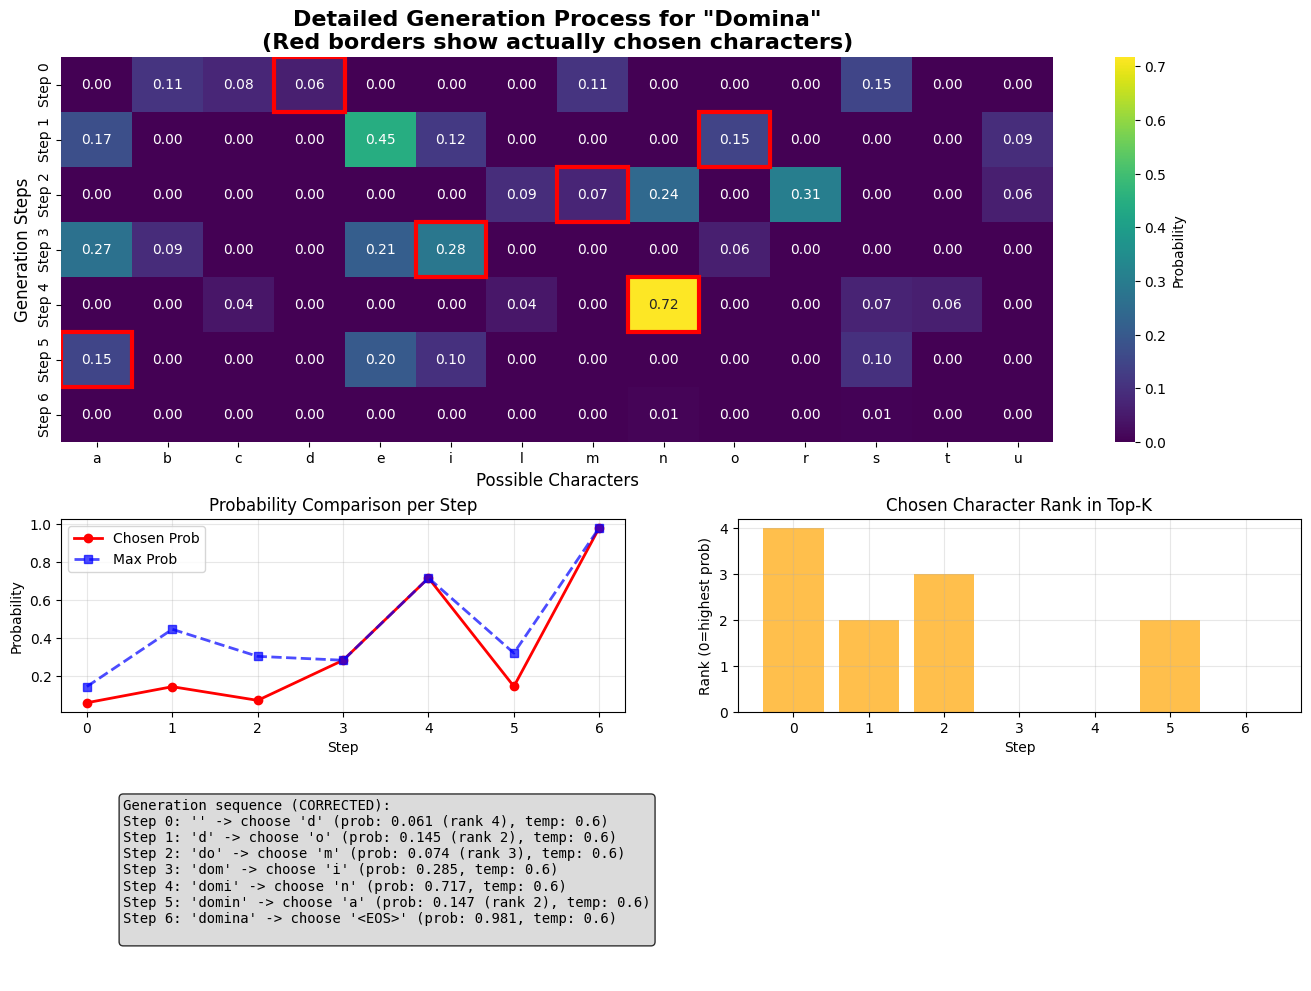

In [ ]:
def create_detailed_generation_visualization(generation_info: List[Dict[str, Any]], name: str, save_path: str) -> None:
    """
    创建详细的名字生成过程可视化

    生成一个综合性的可视化图表，展示名字生成过程的各个方面：
    - 主热力图：显示每一步的字符概率分布，红色边框标出实际选择的字符
    - 概率对比图：比较每步选择字符的概率与最高概率的差异
    - 排名分布图：显示选择字符在Top-K中的排名分布
    - 详细序列文本：逐步展示生成过程，包括概率、排名和温度信息

    Args:
        generation_info: 包含生成过程详细信息的列表，由generate_name函数返回
        name: 生成的名字字符串，用于标题显示
        save_path: 图片保存路径
    """
    if not generation_info:
        return

    fig = plt.figure(figsize=(16, 12))

    gs = fig.add_gridspec(3, 2, height_ratios=[2, 1, 1], hspace=0.3)

    ax1 = fig.add_subplot(gs[0, :])

    steps: int = len(generation_info)
    all_chars: Set[str] = set()
    for info in generation_info:
        all_chars.update(info['top_k_chars'])

    valid_chars: List[str] = [c for c in all_chars if c not in ['<SOS>', '<EOS>', '<PAD>']]
    valid_chars = sorted(valid_chars)

    heatmap_data: np.ndarray = np.zeros((steps, len(valid_chars)))

    for i, info in enumerate(generation_info):
        for j, char in enumerate(valid_chars):
            if char in info['top_k_chars']:
                char_idx: int = info['top_k_chars'].index(char)
                heatmap_data[i, j] = info['top_k_probs'][char_idx]

    sns.heatmap(heatmap_data,
                xticklabels=valid_chars,
                yticklabels=[f"Step {i}" for i in range(steps)],
                cmap='viridis',
                annot=True,
                fmt='.2f',
                cbar_kws={'label': 'Probability'},
                ax=ax1)

    for i, info in enumerate(generation_info):
        chosen_char: str = info['chosen_char']
        if chosen_char in valid_chars:
            char_pos: int = valid_chars.index(chosen_char)
            ax1.add_patch(plt.Rectangle((char_pos, i), 1, 1, fill=False,
                                        edgecolor='red', linewidth=3))

    ax1.set_title(f'Detailed Generation Process for "{name.title()}"\n(Red borders show actually chosen characters)',
                  fontsize=16, fontweight='bold')
    ax1.set_xlabel('Possible Characters', fontsize=12)
    ax1.set_ylabel('Generation Steps', fontsize=12)

    ax2 = fig.add_subplot(gs[1, 0])
    chosen_probs: List[float] = [info['chosen_prob'] for info in generation_info]
    max_probs: List[float] = [max(info['top_k_probs']) for info in generation_info]

    ax2.plot(range(len(chosen_probs)), chosen_probs, 'r-o', linewidth=2, label='Chosen Prob')
    ax2.plot(range(len(max_probs)), max_probs, 'b--s', linewidth=2, label='Max Prob', alpha=0.7)
    ax2.set_title('Probability Comparison per Step')
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Probability')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    ax3 = fig.add_subplot(gs[1, 1])
    chosen_ranks: List[int] = [info['chosen_rank'] for info in generation_info]

    ax3.bar(range(len(chosen_ranks)), chosen_ranks, alpha=0.7, color='orange')
    ax3.set_title('Chosen Character Rank in Top-K')
    ax3.set_xlabel('Step')
    ax3.set_ylabel('Rank (0=highest prob)')
    ax3.grid(True, alpha=0.3)

    ax4 = fig.add_subplot(gs[2, :])
    ax4.axis('off')

    sequence_text: str = "Generation sequence (CORRECTED):\n"
    for i, info in enumerate(generation_info):
        current_seq: str = info['current_sequence']
        chosen_char: str = info['chosen_char']
        chosen_prob: float = info['chosen_prob']
        chosen_rank: int = info['chosen_rank']
        temp: float = info['temperature']

        rank_text: str = f" (rank {chosen_rank})" if chosen_rank > 0 else ""
        sequence_text += f"Step {i}: '{current_seq}' -> choose '{chosen_char}' (prob: {chosen_prob:.3f}{rank_text}, temp: {temp})\n"

    ax4.text(0.05, 0.95, sequence_text, transform=ax4.transAxes, fontsize=10,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


favorite_name, detailed_info = generate_name(model, start_chars="", temperature=0.6)
create_detailed_generation_visualization(
    detailed_info,
    favorite_name,
    f"{RESULT_SAVE_PATH}/detailed_generation_{favorite_name}.png"
)

### 不同温度下的生成示例


In [15]:
for temp in [0.0, 0.5, 1.0]:
    name, info = generate_name(model, start_chars="A", temperature=temp, max_length=8)
    print(f"\nTemperature: {temp}")
    print(f"Generated name: {name}")
    print("Step-by-step process:")
    for step_info in info:
        chosen_char = step_info['chosen_char']
        chosen_prob = step_info['chosen_prob']
        chosen_rank = step_info['chosen_rank']
        current_seq = step_info['current_sequence']

        rank_info = f" (rank {chosen_rank} in top-k)" if chosen_rank > 0 else " (highest prob)"
        print(f"  '{current_seq}' -> '{chosen_char}' (prob: {chosen_prob:.3f}{rank_info})")


Temperature: 0.0
Generated name: a
Step-by-step process:
  'a' -> '<SOS>' (prob: nan (highest prob))
  'a' -> '<SOS>' (prob: nan (highest prob))
  'a' -> '<SOS>' (prob: nan (highest prob))
  'a' -> '<SOS>' (prob: nan (highest prob))
  'a' -> '<SOS>' (prob: nan (highest prob))
  'a' -> '<SOS>' (prob: nan (highest prob))
  'a' -> '<SOS>' (prob: nan (highest prob))
  'a' -> '<SOS>' (prob: nan (highest prob))

Temperature: 0.5
Generated name: ambert
Step-by-step process:
  'a' -> 'm' (prob: 0.047 (rank 3 in top-k))
  'am' -> 'b' (prob: 0.142 (rank 2 in top-k))
  'amb' -> 'e' (prob: 0.195 (rank 1 in top-k))
  'ambe' -> 'r' (prob: 0.951 (highest prob))
  'amber' -> 't' (prob: 0.372 (highest prob))
  'ambert' -> '<EOS>' (prob: 0.797 (highest prob))

Temperature: 1.0
Generated name: arand
Step-by-step process:
  'a' -> 'r' (prob: 0.159 (rank 1 in top-k))
  'ar' -> 'a' (prob: 0.075 (rank 3 in top-k))
  'ara' -> 'n' (prob: 0.182 (highest prob))
  'aran' -> 'd' (prob: 0.242 (highest prob))
  'ar

[Test]: 100%|██████████| 51/51 [00:00<00:00, 220.57it/s, V_Loss=2.1390, V_Acc=0.3296, V_PPL=8.49]


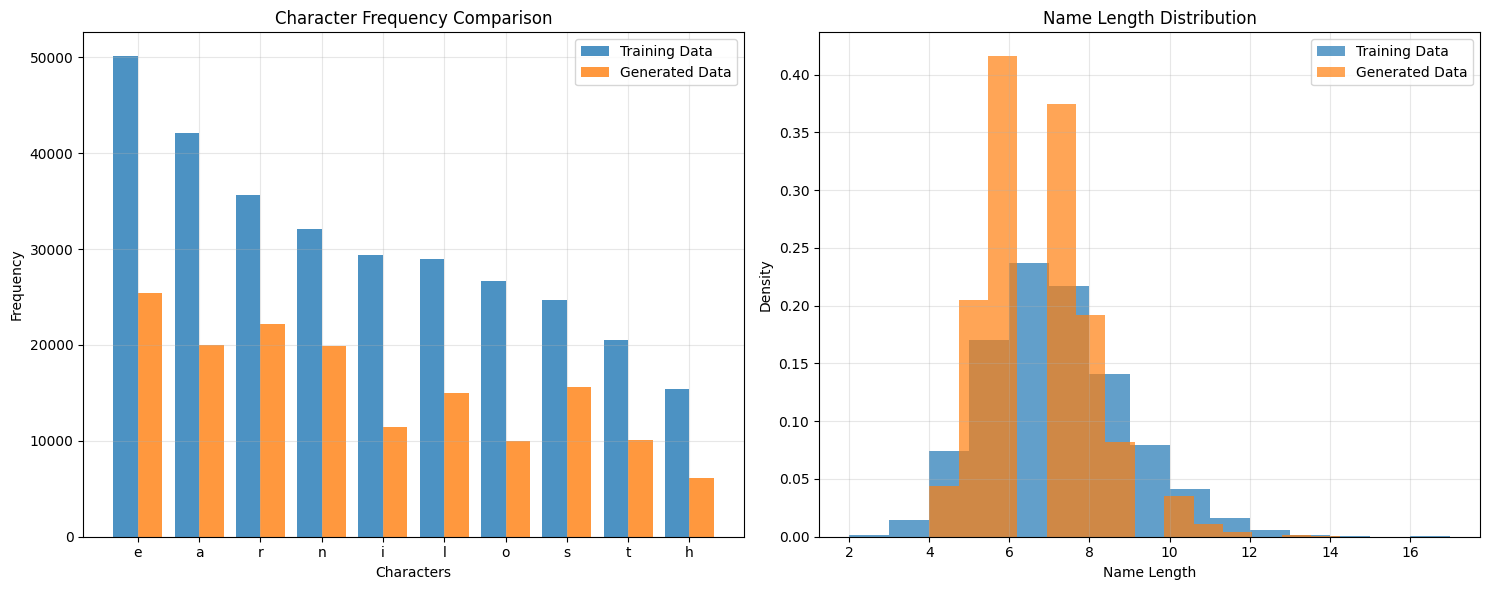

In [16]:
def comprehensive_evaluation() -> Dict[str, Any]:
    """
    对训练好的模型进行全面评估

    执行多维度的模型性能评估，包括：
    - 测试集性能：损失、准确率和困惑度
    - 生成质量评估：生成大量样本并分析其统计特性
    - 多样性分析：计算生成名字的唯一性比例
    - 与训练数据的对比：字符频率分布和长度分布的比较
    - 记忆性检测：检查生成名字与训练数据的重叠情况

    生成可视化图表展示训练数据和生成数据的分布差异，
    并将详细评估结果保存到JSON文件中。

    Returns:
        包含所有评估指标和结果的字典
    """
    test_loss: float
    test_acc: float
    test_loss, test_acc = evaluate(model, test_loader, criterion, device, 'Test')
    test_perplexity: float = calculate_perplexity(test_loss)

    generated_names: List[str] = []
    for _ in range(30000):
        name: str
        name, _ = generate_name(model, temperature=0.8)
        generated_names.append(name)

    lengths: List[int] = [len(name) for name in generated_names]
    unique_names: Set[str] = set(generated_names)

    training_names: Set[str] = set(names)
    overlap: int = len(set(generated_names) & training_names)

    train_char_count: Counter = Counter()
    for name in names:
        train_char_count.update(name)

    gen_char_count: Counter = Counter()
    for name in generated_names:
        gen_char_count.update(name)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    common_chars: List[str] = [item[0] for item in train_char_count.most_common(10)]
    train_freqs: List[int] = [train_char_count[char] for char in common_chars]
    gen_freqs: List[int] = [gen_char_count[char] for char in common_chars]

    x_pos: np.ndarray = np.arange(len(common_chars))

    ax1.bar(x_pos - 0.2, train_freqs, 0.4, label='Training Data', alpha=0.8)
    ax1.bar(x_pos + 0.2, gen_freqs, 0.4, label='Generated Data', alpha=0.8)
    ax1.set_xlabel('Characters')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Character Frequency Comparison')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(common_chars)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    train_lengths: List[int] = [len(name) for name in names]

    ax2.hist(train_lengths, bins=15, alpha=0.7, label='Training Data', density=True)
    ax2.hist(lengths, bins=15, alpha=0.7, label='Generated Data', density=True)
    ax2.set_xlabel('Name Length')
    ax2.set_ylabel('Density')
    ax2.set_title('Name Length Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{RESULT_SAVE_PATH}/character_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()

    evaluation_results: Dict[str, Any] = {
        'test_loss': test_loss,
        'test_accuracy': test_acc,
        'test_perplexity': test_perplexity,
        'generated_names_count': len(generated_names),
        'unique_names_count': len(unique_names),
        'uniqueness_ratio': len(unique_names)/len(generated_names),
        'average_length': np.mean(lengths),
        'training_overlap': overlap,
        'sample_names': generated_names[:50]
    }

    with open(f"{RESULT_SAVE_PATH}/evaluation_results.json", 'w') as f:
        json.dump(evaluation_results, f, indent=2)

    return evaluation_results


eval_results = comprehensive_evaluation()

In [17]:
def save_final_model() -> None:
    """
    保存完整的模型信息和训练结果

    将训练完成的模型及其相关信息保存到文件中，包括：
    - 模型权重参数：完整的state_dict用于模型恢复
    - 模型配置：网络架构参数，便于重建模型结构
    - 训练配置：训练过程中使用的超参数设置
    - 词汇表映射：字符与索引的双向映射关系
    - 训练历史：完整的训练过程指标记录
    - 数据集信息：训练、验证、测试集的规模统计

    同时单独保存词汇表到JSON文件，便于后续推理使用。
    所有信息以字典形式组织，确保模型的完整可复现性。
    """
    final_model_info: Dict[str, Any] = {
        'model_state_dict': model.state_dict(),
        'model_config': {
            'vocab_size': processor.vocab_size,
            'embedding_dim': embedding_dim,
            'hidden_dim': hidden_dim,
            'num_layers': num_layers,
            'dropout': dropout
        },
        'training_config': {
            'num_epochs': len(train_losses),
            'batch_size': batch_size,
            'learning_rate': learning_rate,
            'weight_decay': weight_decay
        },
        'vocabulary': {
            'char_to_idx': char_to_idx,
            'idx_to_char': idx_to_char,
            'vocab_size': processor.vocab_size,
            'max_length': processor.max_length
        },
        'training_history': {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accuracies': train_accuracies,
            'val_accuracies': val_accuracies,
            'train_perplexities': train_perplexities,
            'val_perplexities': val_perplexities,
            'learning_rate_history': learning_rate_history
        },
        'dataset_info': {
            'total_names': len(names),
            'train_size': len(train_names),
            'val_size': len(val_names),
            'test_size': len(test_names)
        }
    }

    torch.save(final_model_info, f"{MODEL_SAVE_PATH}/complete_model.pth")

    vocabulary_data: Dict[str, Union[Dict[str, int], Dict[str, str], int]] = {
        'char_to_idx': char_to_idx,
        'idx_to_char': {str(k): v for k, v in idx_to_char.items()},
        'vocab_size': processor.vocab_size
    }

    with open(f"{MODEL_SAVE_PATH}/vocabulary.json", 'w') as f:
        json.dump(vocabulary_data, f, indent=2)


save_final_model()

### 数据整理


In [18]:
print(f"Dataset: {len(names)} unique names")
print(f"Model: LSTM with {sum(p.numel() for p in model.parameters())} parameters")
print(f"Training: {len(train_losses)} epochs")
print(f"Performance: {eval_results['test_accuracy']:.3f} accuracy, {eval_results['test_perplexity']:.2f} perplexity")
print(f"Generation: {eval_results['uniqueness_ratio']:.1%} unique names")
print(f"Favorite name: '{favorite_name.title()}'")
print(f"Final learning rate: {learning_rate_history[-1]:.6f}")

Dataset: 64740 unique names
Model: LSTM with 237021 parameters
Training: 50 epochs
Performance: 0.330 accuracy, 8.49 perplexity
Generation: 48.0% unique names
Favorite name: 'Domina'
Final learning rate: 0.000250


In [20]:
class BidirectionalNameGenerator(nn.Module):
    """
    双向名字生成器神经网络模型

    使用双向LSTM架构构建的序列模型，能够同时利用前向和后向的上下文信息。
    特别适用于填补缺失字符的任务，通过掩码机制可以在已知部分字符的情况下
    预测缺失的字符。模型输出维度是单向LSTM的两倍，包含更丰富的上下文信息。
    """

    def __init__(self, vocab_size: int, embedding_dim: int, hidden_dim: int,
                 num_layers: int = 3, dropout: float = 0.2) -> None:
        """
        初始化双向名字生成器模型

        Args:
            vocab_size: 词汇表大小，包含所有字符和特殊标记的总数
            embedding_dim: 嵌入层维度，字符向量的维度大小
            hidden_dim: LSTM隐藏层维度（每个方向的维度）
            num_layers: LSTM层数，默认为3层
            dropout: Dropout比率，用于防止过拟合，默认为0.2
        """
        super(BidirectionalNameGenerator, self).__init__()
        self.vocab_size: int = vocab_size
        self.embedding_dim: int = embedding_dim
        self.hidden_dim: int = hidden_dim
        self.num_layers: int = num_layers

        # Embedding layer
        self.embedding: nn.Embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        # Bidirectional LSTM
        self.lstm: nn.LSTM = nn.LSTM(embedding_dim, hidden_dim, num_layers,
                                     dropout=dropout, batch_first=True, bidirectional=True)

        # Output layer
        self.fc: nn.Linear = nn.Linear(hidden_dim * 2, vocab_size)
        self.dropout: nn.Dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        模型前向传播

        将输入序列通过嵌入层、双向LSTM层和输出层，生成每个位置的字符概率分布。
        支持掩码机制，可以屏蔽某些位置的输入，用于填补缺失字符的任务。

        Args:
            x: 输入张量，形状为 (batch_size, seq_len)，包含字符索引序列
            mask: 掩码张量，形状为 (batch_size, seq_len)，可选参数
                  True表示保留该位置，False表示屏蔽该位置

        Returns:
            输出张量，形状为 (batch_size, seq_len, vocab_size)
        """
        embedded: torch.Tensor = self.embedding(x)

        if mask is not None:
            embedded = embedded * mask.unsqueeze(-1).float()

        lstm_out: torch.Tensor
        lstm_out, _ = self.lstm(embedded)
        lstm_out = self.dropout(lstm_out)
        output: torch.Tensor = self.fc(lstm_out)

        return output


def create_masked_input(name_indices: List[int], mask_positions: List[int]) -> Tuple[List[int], torch.Tensor]:
    """
    创建带掩码的输入序列

    根据指定的掩码位置，将输入序列中对应位置的字符替换为填充标记，
    并生成相应的掩码张量。用于双向模型的字符填补任务。

    Args:
        name_indices: 原始名字的字符索引列表
        mask_positions: 需要掩码的位置列表

    Returns:
        掩码后的输入序列和掩码张量的元组
    """
    masked_input: List[int] = name_indices.copy()
    mask: torch.Tensor = torch.ones(len(name_indices), dtype=torch.bool)

    for pos in mask_positions:
        if 0 <= pos < len(masked_input):
            masked_input[pos] = char_to_idx['<PAD>']
            mask[pos] = False

    return masked_input, mask


def fill_missing_chars(model: nn.Module, partial_name: str, missing_positions: List[int],
                       max_iterations: int = 10) -> str:
    """
    填补名字中的缺失字符

    使用训练好的双向模型填补部分名字中指定位置的缺失字符。
    通过迭代过程逐步优化预测结果，直到收敛或达到最大迭代次数。
    利用双向上下文信息提高预测准确性。

    Args:
        model: 训练好的双向名字生成模型
        partial_name: 部分已知的名字字符串
        missing_positions: 缺失字符的位置列表（相对于完整序列，包含SOS和EOS）
        max_iterations: 最大迭代次数，默认为10次

    Returns:
        填补缺失字符后的完整名字字符串
    """
    model.eval()

    name_indices: List[int] = [char_to_idx['<SOS>']]
    for char in partial_name:
        if char in char_to_idx:
            name_indices.append(char_to_idx[char])
        else:
            name_indices.append(char_to_idx['<PAD>'])
    name_indices.append(char_to_idx['<EOS>'])

    current_name: List[int] = name_indices.copy()

    with torch.no_grad():
        for iteration in range(max_iterations):
            mask: torch.Tensor = torch.ones(len(current_name), dtype=torch.bool)
            for pos in missing_positions:
                if 0 <= pos < len(current_name):
                    mask[pos] = False

            input_tensor: torch.Tensor = torch.tensor([current_name], dtype=torch.long).to(device)
            mask_tensor: torch.Tensor = mask.unsqueeze(0).to(device)

            output: torch.Tensor = model(input_tensor, mask_tensor)
            output = output[0]

            updated: bool = False
            for pos in missing_positions:
                if 0 <= pos < len(current_name):
                    probs: torch.Tensor = F.softmax(output[pos], dim=-1)
                    predicted_idx: int = torch.argmax(probs).item()

                    if current_name[pos] != predicted_idx:
                        current_name[pos] = predicted_idx
                        updated = True

            if not updated:
                break

    result: str = ""
    for idx in current_name[1:-1]:
        char: str = idx_to_char[idx]
        if char not in ['<SOS>', '<EOS>', '<PAD>']:
            result += char

    return result


bidirectional_model: BidirectionalNameGenerator = BidirectionalNameGenerator(
    vocab_size=processor.vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim//2,
    num_layers=num_layers,
    dropout=dropout
).to(device)

In [21]:
bidirectional_model

BidirectionalNameGenerator(
  (embedding): Embedding(29, 64, padding_idx=2)
  (lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Linear(in_features=128, out_features=29, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

### 双向 LSTM 模型训练与评估


In [ ]:
def train_bidirectional_model():
    """训练双向LSTM模型用于字符填补任务 - 使用批量训练"""

    def create_masked_dataset(encoded_names, mask_ratio=0.3):
        """创建用于训练的掩码数据集"""
        masked_data = []

        for encoded_name in encoded_names:
            # 随机选择要掩码的位置（不包括SOS和EOS）
            inner_positions = list(range(1, len(encoded_name) - 1))
            if len(inner_positions) == 0:
                continue

            num_mask = max(1, int(len(inner_positions) * mask_ratio))
            mask_positions = random.sample(inner_positions, min(num_mask, len(inner_positions)))

            # 创建输入和目标
            input_seq = encoded_name.copy()
            target_seq = encoded_name.copy()
            mask = [True] * len(encoded_name)

            for pos in mask_positions:
                input_seq[pos] = char_to_idx['<PAD>']
                mask[pos] = False

            masked_data.append({
                'input': input_seq,
                'target': target_seq,
                'mask': mask,
                'mask_positions': mask_positions
            })

        return masked_data

    def pad_batch(batch):
        """对批次数据进行填充，使所有序列长度一致"""
        max_len = max(len(item['input']) for item in batch)

        batch_input = []
        batch_target = []
        batch_mask = []
        batch_loss_mask = []

        for item in batch:
            input_seq = item['input'].copy()
            target_seq = item['target'].copy()
            mask = item['mask'].copy()
            mask_positions = item['mask_positions']

            loss_mask = [False] * len(input_seq)
            for pos in mask_positions:
                if 0 <= pos < len(loss_mask):
                    loss_mask[pos] = True

            pad_len = max_len - len(input_seq)
            if pad_len > 0:
                input_seq.extend([char_to_idx['<PAD>']] * pad_len)
                target_seq.extend([char_to_idx['<PAD>']] * pad_len)
                mask.extend([False] * pad_len)
                loss_mask.extend([False] * pad_len)

            batch_input.append(input_seq)
            batch_target.append(target_seq)
            batch_mask.append(mask)
            batch_loss_mask.append(loss_mask)

        return (torch.tensor(batch_input, dtype=torch.long),
                torch.tensor(batch_target, dtype=torch.long),
                torch.tensor(batch_mask, dtype=torch.bool),
                torch.tensor(batch_loss_mask, dtype=torch.bool))

    print("Creating masked training dataset...")
    masked_train_data = create_masked_dataset(train_names)
    masked_val_data = create_masked_dataset(val_names)

    print(f"Training data size: {len(masked_train_data)}")
    print(f"Validation data size: {len(masked_val_data)}")

    bi_epochs = 50
    bi_lr = 0.001
    batch_size = 256

    bi_optimizer = optim.Adam(bidirectional_model.parameters(), lr=bi_lr)
    bi_criterion = nn.CrossEntropyLoss(ignore_index=char_to_idx['<PAD>'])

    bi_train_losses = []
    bi_val_losses = []
    bi_train_accuracies = []
    bi_val_accuracies = []

    print(f"Training bidirectional model for {bi_epochs} epochs with batch_size={batch_size}...")

    for epoch in range(bi_epochs):
        bidirectional_model.train()
        total_loss = 0
        total_correct = 0
        total_masked_tokens = 0

        random.shuffle(masked_train_data)
        train_batches = [masked_train_data[i:i+batch_size]
                         for i in range(0, len(masked_train_data), batch_size)]

        pbar = tqdm(train_batches, desc=f'Bi-Epoch {epoch+1}/{bi_epochs} [Train]')

        for batch in pbar:
            bi_optimizer.zero_grad()

            batch_input, batch_target, batch_mask, batch_loss_mask = pad_batch(batch)
            batch_input = batch_input.to(device)
            batch_target = batch_target.to(device)
            batch_mask = batch_mask.to(device)
            batch_loss_mask = batch_loss_mask.to(device)

            output = bidirectional_model(batch_input, batch_mask)

            output_flat = output.view(-1, output.size(-1))  # (batch_size * seq_len, vocab_size)
            target_flat = batch_target.view(-1)  # (batch_size * seq_len)
            loss_mask_flat = batch_loss_mask.view(-1)  # (batch_size * seq_len)

            if loss_mask_flat.sum() > 0:
                masked_output = output_flat[loss_mask_flat]
                masked_target = target_flat[loss_mask_flat]

                loss = bi_criterion(masked_output, masked_target)

                pred = masked_output.argmax(dim=-1)
                correct = (pred == masked_target).sum().item()

                loss.backward()
                bi_optimizer.step()

                total_loss += loss.item()
                total_correct += correct
                total_masked_tokens += masked_target.size(0)

            current_acc = total_correct / total_masked_tokens if total_masked_tokens > 0 else 0
            pbar.set_postfix({
                'Loss': f'{total_loss / (pbar.n + 1):.4f}',
                'Acc': f'{current_acc:.4f}'
            })

        train_loss = total_loss / len(train_batches) if train_batches else 0
        train_acc = total_correct / total_masked_tokens if total_masked_tokens > 0 else 0

        bidirectional_model.eval()
        val_loss = 0
        val_correct = 0
        val_masked_tokens = 0

        val_batches = [masked_val_data[i:i+batch_size]
                       for i in range(0, len(masked_val_data), batch_size)]

        with torch.no_grad():
            val_pbar = tqdm(val_batches, desc='[Val]')
            for batch in val_pbar:
                batch_input, batch_target, batch_mask, batch_loss_mask = pad_batch(batch)
                batch_input = batch_input.to(device)
                batch_target = batch_target.to(device)
                batch_mask = batch_mask.to(device)
                batch_loss_mask = batch_loss_mask.to(device)

                output = bidirectional_model(batch_input, batch_mask)

                output_flat = output.view(-1, output.size(-1))
                target_flat = batch_target.view(-1)
                loss_mask_flat = batch_loss_mask.view(-1)

                if loss_mask_flat.sum() > 0:
                    masked_output = output_flat[loss_mask_flat]
                    masked_target = target_flat[loss_mask_flat]

                    loss = bi_criterion(masked_output, masked_target)
                    val_loss += loss.item()

                    pred = masked_output.argmax(dim=-1)
                    correct = (pred == masked_target).sum().item()
                    val_correct += correct
                    val_masked_tokens += masked_target.size(0)

                current_val_acc = val_correct / val_masked_tokens if val_masked_tokens > 0 else 0
                val_pbar.set_postfix({
                    'V_Loss': f'{val_loss / (val_pbar.n + 1):.4f}',
                    'V_Acc': f'{current_val_acc:.4f}'
                })

        val_loss = val_loss / len(val_batches) if val_batches else 0
        val_acc = val_correct / val_masked_tokens if val_masked_tokens > 0 else 0

        bi_train_losses.append(train_loss)
        bi_val_losses.append(val_loss)
        bi_train_accuracies.append(train_acc)
        bi_val_accuracies.append(val_acc)

        print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

    torch.save({
        'model_state_dict': bidirectional_model.state_dict(),
        'training_history': {
            'train_losses': bi_train_losses,
            'val_losses': bi_val_losses,
            'train_accuracies': bi_train_accuracies,
            'val_accuracies': bi_val_accuracies
        },
        'training_config': {
            'epochs': bi_epochs,
            'batch_size': batch_size,
            'learning_rate': bi_lr,
            'mask_ratio': 0.3
        }
    }, f"{MODEL_SAVE_PATH}/bidirectional_model.pth")

    return bi_train_losses, bi_val_losses, bi_train_accuracies, bi_val_accuracies


bi_train_losses, bi_val_losses, bi_train_accuracies, bi_val_accuracies = train_bidirectional_model()

print(f"Final Training Accuracy: {bi_train_accuracies[-1]:.4f}")
print(f"Final Validation Accuracy: {bi_val_accuracies[-1]:.4f}")

Creating masked training dataset...
Training data size: 45318
Validation data size: 12948
Training bidirectional model for 50 epochs with batch_size=256...


[Val]: 100%|██████████| 51/51 [00:00<00:00, 88.63it/s, V_Loss=2.6847, V_Acc=0.3116]  


Epoch 1: Train Loss: 2.2363, Train Acc: 0.2927, Val Loss: 2.1583, Val Acc: 0.3116


[Val]: 100%|██████████| 51/51 [00:00<00:00, 117.66it/s, V_Loss=2.2201, V_Acc=0.3194] 


Epoch 2: Train Loss: 2.1812, Train Acc: 0.3064, Val Loss: 2.1331, Val Acc: 0.3194


...

Epoch 48: Train Loss: 1.8302, Train Acc: 0.4061, Val Loss: 2.0348, Val Acc: 0.3535


[Val]: 100%|██████████| 51/51 [00:00<00:00, 119.30it/s, V_Loss=2.0749, V_Acc=0.3550] 


Epoch 49: Train Loss: 1.8334, Train Acc: 0.4056, Val Loss: 2.0342, Val Acc: 0.3550


[Val]: 100%|██████████| 51/51 [00:00<00:00, 120.17it/s, V_Loss=2.6661, V_Acc=0.3541] 


Epoch 50: Train Loss: 1.8395, Train Acc: 0.4052, Val Loss: 2.0388, Val Acc: 0.3541
Final Training Accuracy: 0.4052
Final Validation Accuracy: 0.3541


### 测试 Bidirectional 模型性能


In [ ]:
def test_bidirectional_performance():
    """测试双向模型的字符填补性能"""

    test_cases = [
        {"name": "alexander", "missing_pos": [2, 5, 7], "description": "Alexander with missing 'e', 'n', 'e'"},
        {"name": "elizabeth", "missing_pos": [1, 4, 6], "description": "Elizabeth with missing 'l', 'a', 'e'"},
        {"name": "christopher", "missing_pos": [0, 3, 8], "description": "Christopher with missing 'c', 'i', 'h'"},
        {"name": "samantha", "missing_pos": [2, 5], "description": "Samantha with missing 'm', 't'"},
        {"name": "michael", "missing_pos": [1, 4], "description": "Michael with missing 'i', 'a'"}
    ]

    results = []

    for i, case in enumerate(test_cases):
        original = case["name"]
        missing_positions = [pos + 1 for pos in case["missing_pos"]]

        partial_display = list(original)
        for pos in case["missing_pos"]:
            if pos < len(partial_display):
                partial_display[pos] = '?'
        partial_str = ''.join(partial_display)

        try:
            predicted = fill_missing_chars(bidirectional_model, original, missing_positions)
        except Exception as e:
            print(f"Error in prediction for {original}: {e}")
            predicted = original

        correct_chars = 0
        for pos in case["missing_pos"]:
            if pos < len(predicted) and pos < len(original):
                if predicted[pos] == original[pos]:
                    correct_chars += 1

        accuracy = correct_chars / len(case["missing_pos"]) if case["missing_pos"] else 0

        result = {
            'original': original,
            'partial': partial_str,
            'predicted': predicted,
            'missing_positions': case["missing_pos"],
            'accuracy': accuracy,
            'description': case["description"]
        }
        results.append(result)

        print(f"Test {i+1}: {case['description']}")
        print(f"  Original:  {original}")
        print(f"  Partial:   {partial_str}")
        print(f"  Predicted: {predicted}")
        print(f"  Accuracy:  {accuracy:.2%}")
        print()

    return results


test_results = test_bidirectional_performance()

Test 1: Alexander with missing 'e', 'n', 'e'
  Original:  alexander
  Partial:   al?xa?d?r
  Predicted: allxander
  Accuracy:  66.67%

Test 2: Elizabeth with missing 'l', 'a', 'e'
  Original:  elizabeth
  Partial:   e?iz?b?th
  Predicted: elizebeth
  Accuracy:  66.67%

Test 3: Christopher with missing 'c', 'i', 'h'
  Original:  christopher
  Partial:   ?hr?stop?er
  Predicted: shrnstopfer
  Accuracy:  0.00%

Test 4: Samantha with missing 'm', 't'
  Original:  samantha
  Partial:   sa?an?ha
  Predicted: samantha
  Accuracy:  100.00%

Test 5: Michael with missing 'i', 'a'
  Original:  michael
  Partial:   m?ch?el
  Predicted: micheel
  Accuracy:  50.00%



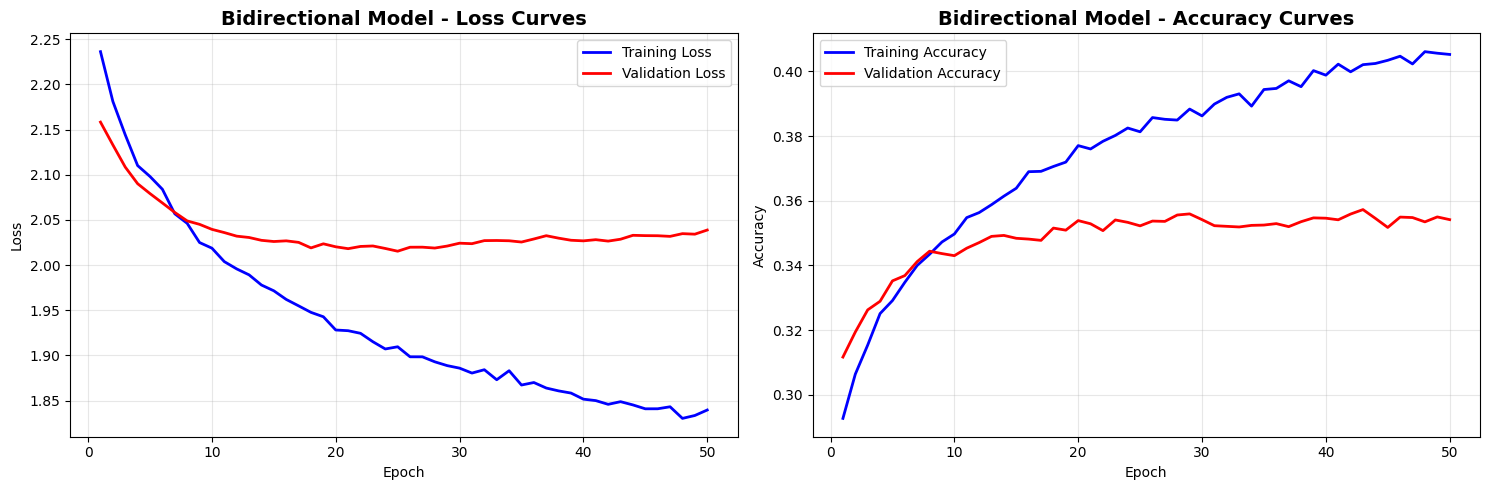

In [27]:
def plot_bidirectional_training():
    """绘制双向模型训练曲线"""

    if not bi_train_losses or not bi_val_losses:
        print("No training history available for plotting.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    epochs = range(1, len(bi_train_losses) + 1)
    axes[0].plot(epochs, bi_train_losses, label='Training Loss', color='blue', linewidth=2)
    axes[0].plot(epochs, bi_val_losses, label='Validation Loss', color='red', linewidth=2)
    axes[0].set_title('Bidirectional Model - Loss Curves', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, bi_train_accuracies, label='Training Accuracy', color='blue', linewidth=2)
    axes[1].plot(epochs, bi_val_accuracies, label='Validation Accuracy', color='red', linewidth=2)
    axes[1].set_title('Bidirectional Model - Accuracy Curves', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{RESULT_SAVE_PATH}/bidirectional_training_curves.png", dpi=300, bbox_inches='tight')
    plt.show()


plot_bidirectional_training()

### 字符填补过程可视化


Creating character completion visualizations...

Visualizing completion process for: alexander


/var/folders/j8/mfdp3rfj6qz1xhlkc79_7qyw0000gn/T/ipykernel_75981/2427973720.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


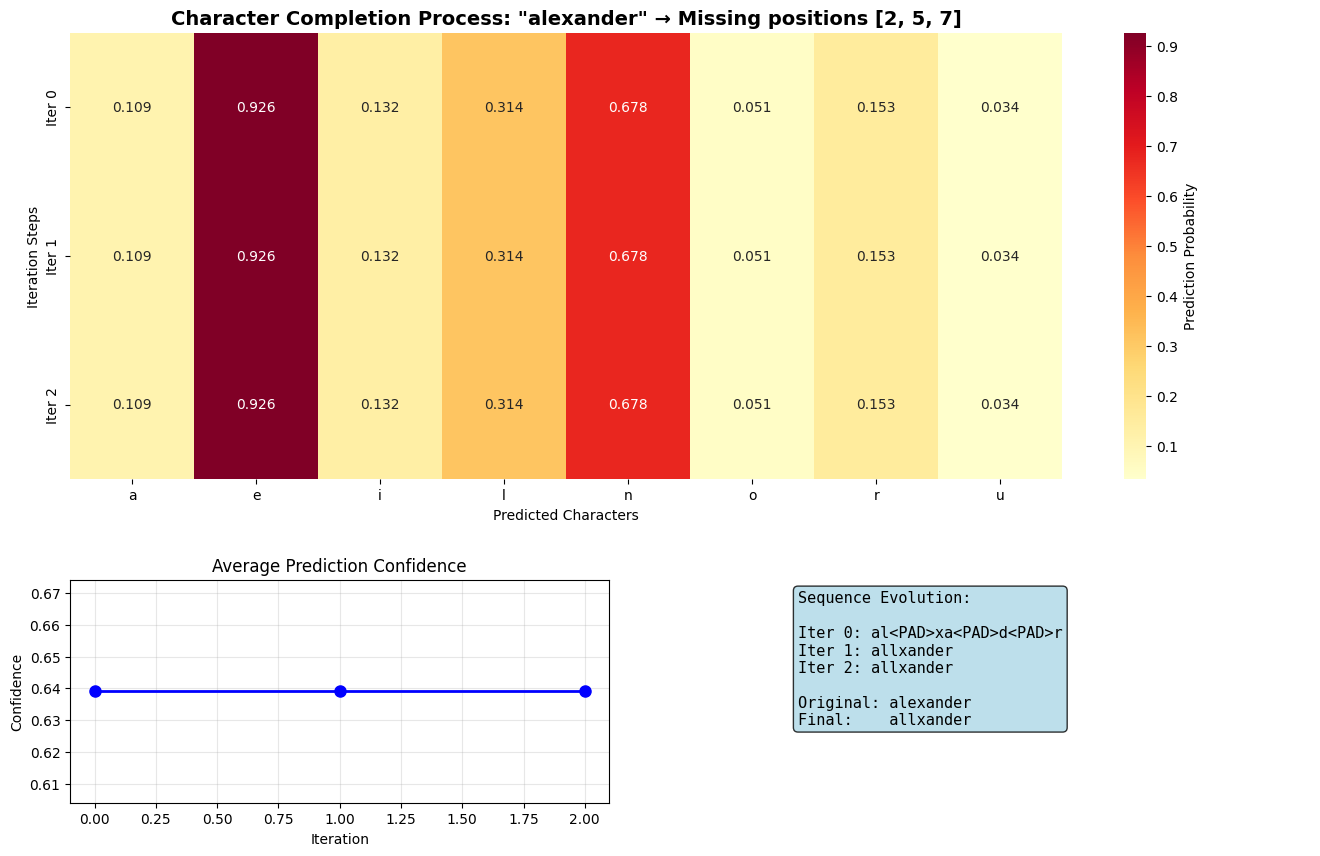


Visualizing completion process for: elizabeth


/var/folders/j8/mfdp3rfj6qz1xhlkc79_7qyw0000gn/T/ipykernel_75981/2427973720.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


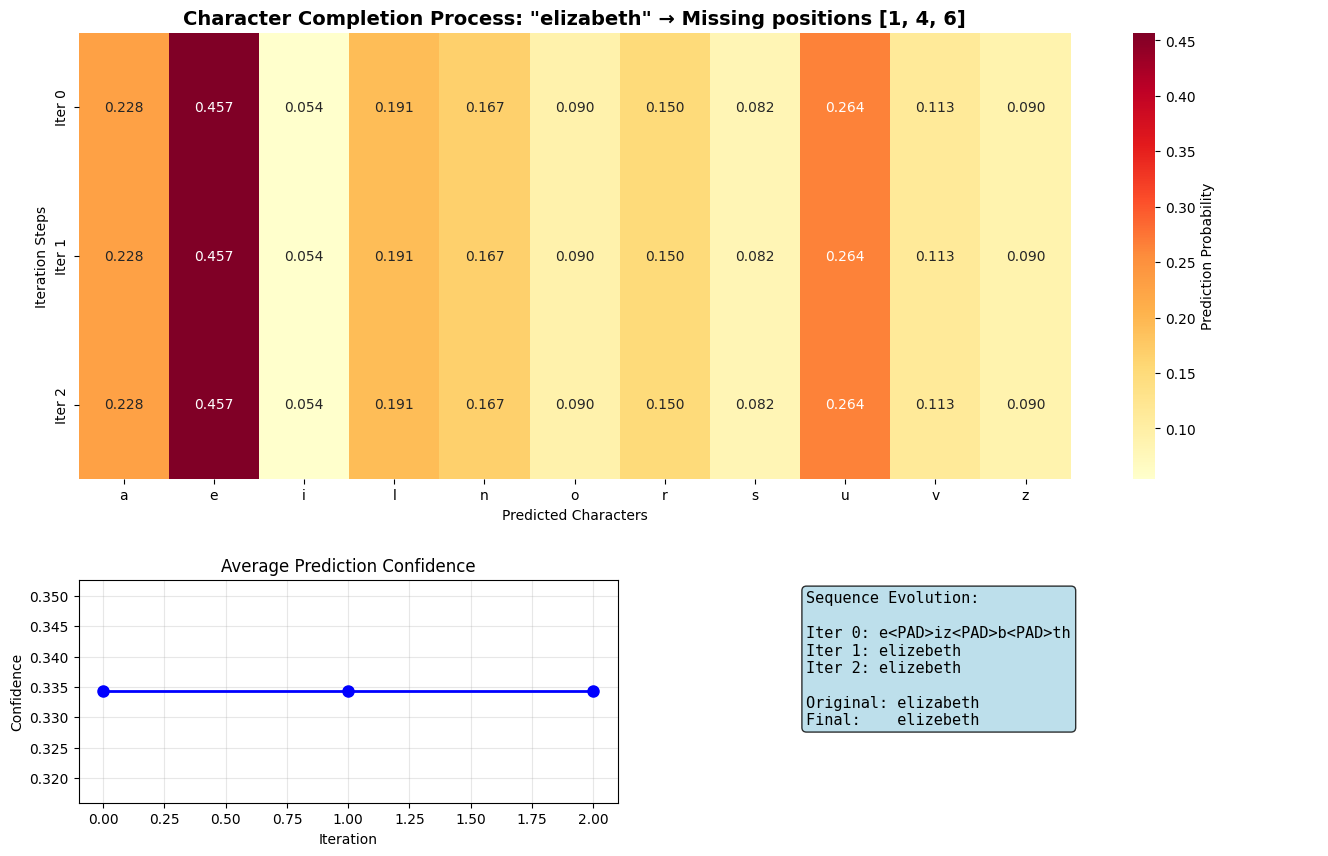


Visualizing completion process for: christopher


/var/folders/j8/mfdp3rfj6qz1xhlkc79_7qyw0000gn/T/ipykernel_75981/2427973720.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


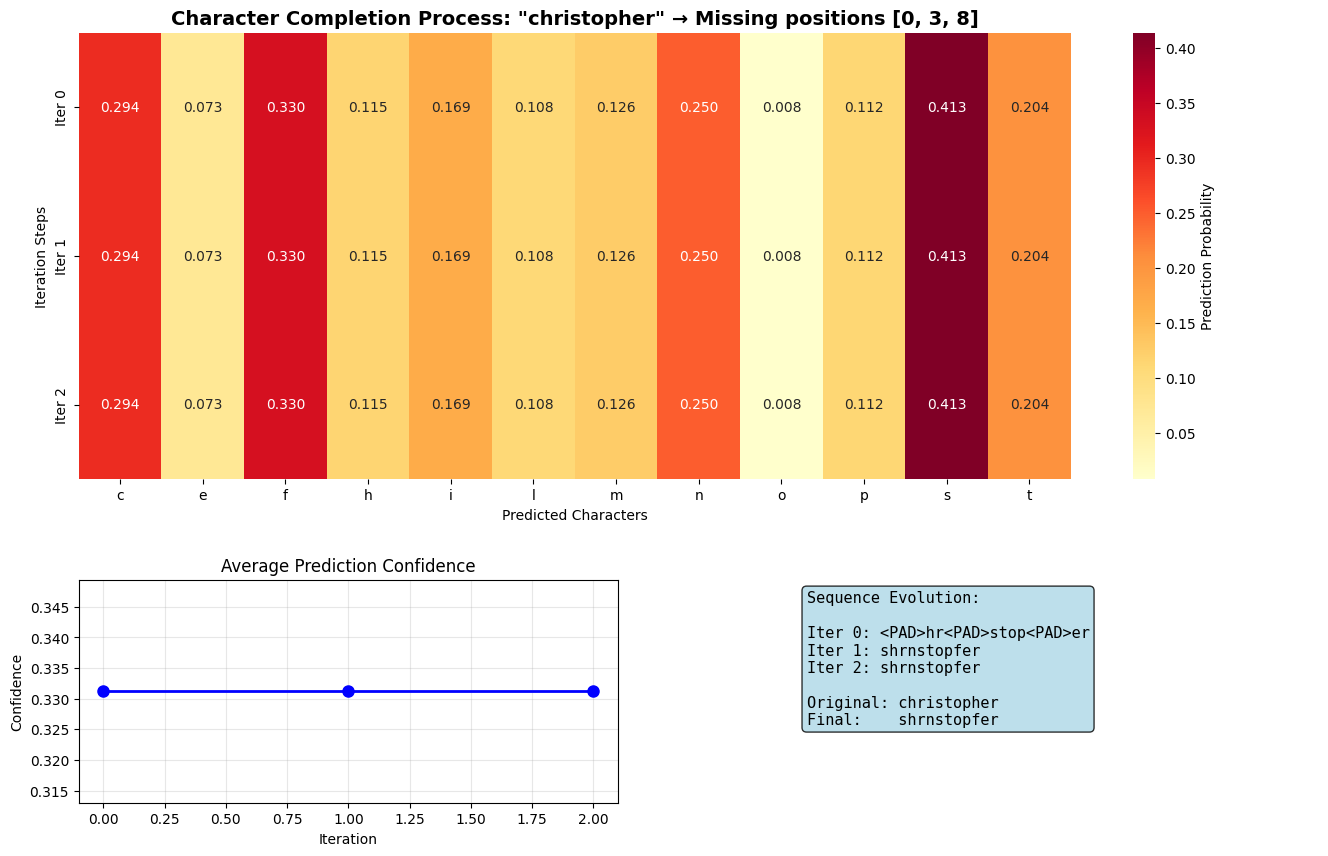

In [28]:
def visualize_character_completion(model, test_case, save_path=None):
    """可视化字符填补过程"""

    original = test_case["name"]
    missing_positions = [pos + 1 for pos in test_case["missing_pos"]]

    name_indices = [char_to_idx['<SOS>']]
    for char in original:
        if char in char_to_idx:
            name_indices.append(char_to_idx[char])
        else:
            name_indices.append(char_to_idx['<PAD>'])
    name_indices.append(char_to_idx['<EOS>'])

    masked_input = name_indices.copy()
    for pos in missing_positions:
        if 0 <= pos < len(masked_input):
            masked_input[pos] = char_to_idx['<PAD>']

    model.eval()
    iterations_data = []

    current_name = masked_input.copy()

    with torch.no_grad():
        for iteration in range(5):
            mask = [True] * len(current_name)
            for pos in missing_positions:
                if 0 <= pos < len(current_name):
                    mask[pos] = False

            input_tensor = torch.tensor([current_name], dtype=torch.long).to(device)
            mask_tensor = torch.tensor([mask], dtype=torch.bool).to(device)

            output = model(input_tensor, mask_tensor)[0]

            iteration_info = {
                'iteration': iteration,
                'current_sequence': [idx_to_char[idx] for idx in current_name],
                'predictions': {},
                'confidences': {}
            }

            for pos in missing_positions:
                if 0 <= pos < len(current_name):
                    probs = F.softmax(output[pos], dim=-1)
                    top_chars = []
                    top_probs = []

                    top_k_probs, top_k_indices = torch.topk(probs, 5)
                    for prob, idx in zip(top_k_probs, top_k_indices):
                        char = idx_to_char[idx.item()]
                        if char not in ['<SOS>', '<EOS>', '<PAD>']:
                            top_chars.append(char)
                            top_probs.append(prob.item())

                    if top_chars:
                        iteration_info['predictions'][pos] = {
                            'chars': top_chars,
                            'probs': top_probs,
                            'predicted_char': top_chars[0],
                            'confidence': top_probs[0]
                        }

                        predicted_idx = torch.argmax(probs).item()
                        current_name[pos] = predicted_idx

            iterations_data.append(iteration_info)

            if iteration > 0:
                prev_seq = iterations_data[iteration-1]['current_sequence']
                current_seq = iteration_info['current_sequence']
                if prev_seq == current_seq:
                    break

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.3, wspace=0.3)

    ax1 = fig.add_subplot(gs[0, :])

    iterations = len(iterations_data)
    if iterations == 0:
        print("No iteration data available for visualization.")
        return

    missing_chars = set()
    for iter_data in iterations_data:
        for pos in missing_positions:
            if pos in iter_data['predictions']:
                missing_chars.update(iter_data['predictions'][pos]['chars'])

    if not missing_chars:
        print("No character predictions available for visualization.")
        return

    missing_chars = sorted(list(missing_chars))
    heatmap_data = np.zeros((iterations, len(missing_chars)))

    for i, iter_data in enumerate(iterations_data):
        for j, char in enumerate(missing_chars):
            max_prob = 0
            for pos in missing_positions:
                if pos in iter_data['predictions']:
                    pred_data = iter_data['predictions'][pos]
                    if char in pred_data['chars']:
                        char_idx = pred_data['chars'].index(char)
                        max_prob = max(max_prob, pred_data['probs'][char_idx])
            heatmap_data[i, j] = max_prob

    sns.heatmap(heatmap_data,
                xticklabels=missing_chars,
                yticklabels=[f"Iter {i}" for i in range(iterations)],
                cmap='YlOrRd',
                annot=True,
                fmt='.3f',
                cbar_kws={'label': 'Prediction Probability'},
                ax=ax1)

    ax1.set_title(f'Character Completion Process: "{original}" → Missing positions {test_case["missing_pos"]}',
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Predicted Characters')
    ax1.set_ylabel('Iteration Steps')

    ax2 = fig.add_subplot(gs[1, 0])

    avg_confidences = []
    for iter_data in iterations_data:
        confidences = [pred['confidence'] for pred in iter_data['predictions'].values()]
        avg_confidences.append(np.mean(confidences) if confidences else 0)

    if avg_confidences:
        ax2.plot(range(len(avg_confidences)), avg_confidences, 'bo-', linewidth=2, markersize=8)
        ax2.set_title('Average Prediction Confidence')
        ax2.set_xlabel('Iteration')
        ax2.set_ylabel('Confidence')
        ax2.grid(True, alpha=0.3)

    ax3 = fig.add_subplot(gs[1, 1])
    ax3.axis('off')

    sequence_text = "Sequence Evolution:\n\n"
    for i, iter_data in enumerate(iterations_data):
        seq = ''.join(iter_data['current_sequence'][1:-1])
        sequence_text += f"Iter {i}: {seq}\n"

    sequence_text += f"\nOriginal: {original}\n"
    if iterations_data:
        final_seq = ''.join(iterations_data[-1]['current_sequence'][1:-1])
        sequence_text += f"Final:    {final_seq}"

    ax3.text(0.05, 0.95, sequence_text, transform=ax3.transAxes, fontsize=11,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


print("Creating character completion visualizations...")
for i, result in enumerate(test_results[:3]):
    print(f"\nVisualizing completion process for: {result['original']}")
    test_case = {
        "name": result['original'],
        "missing_pos": result['missing_positions']
    }
    visualize_character_completion(
        bidirectional_model,
        test_case,
        f"{RESULT_SAVE_PATH}/character_completion_{result['original']}.png"
    )

### 双向模型综合性能分析


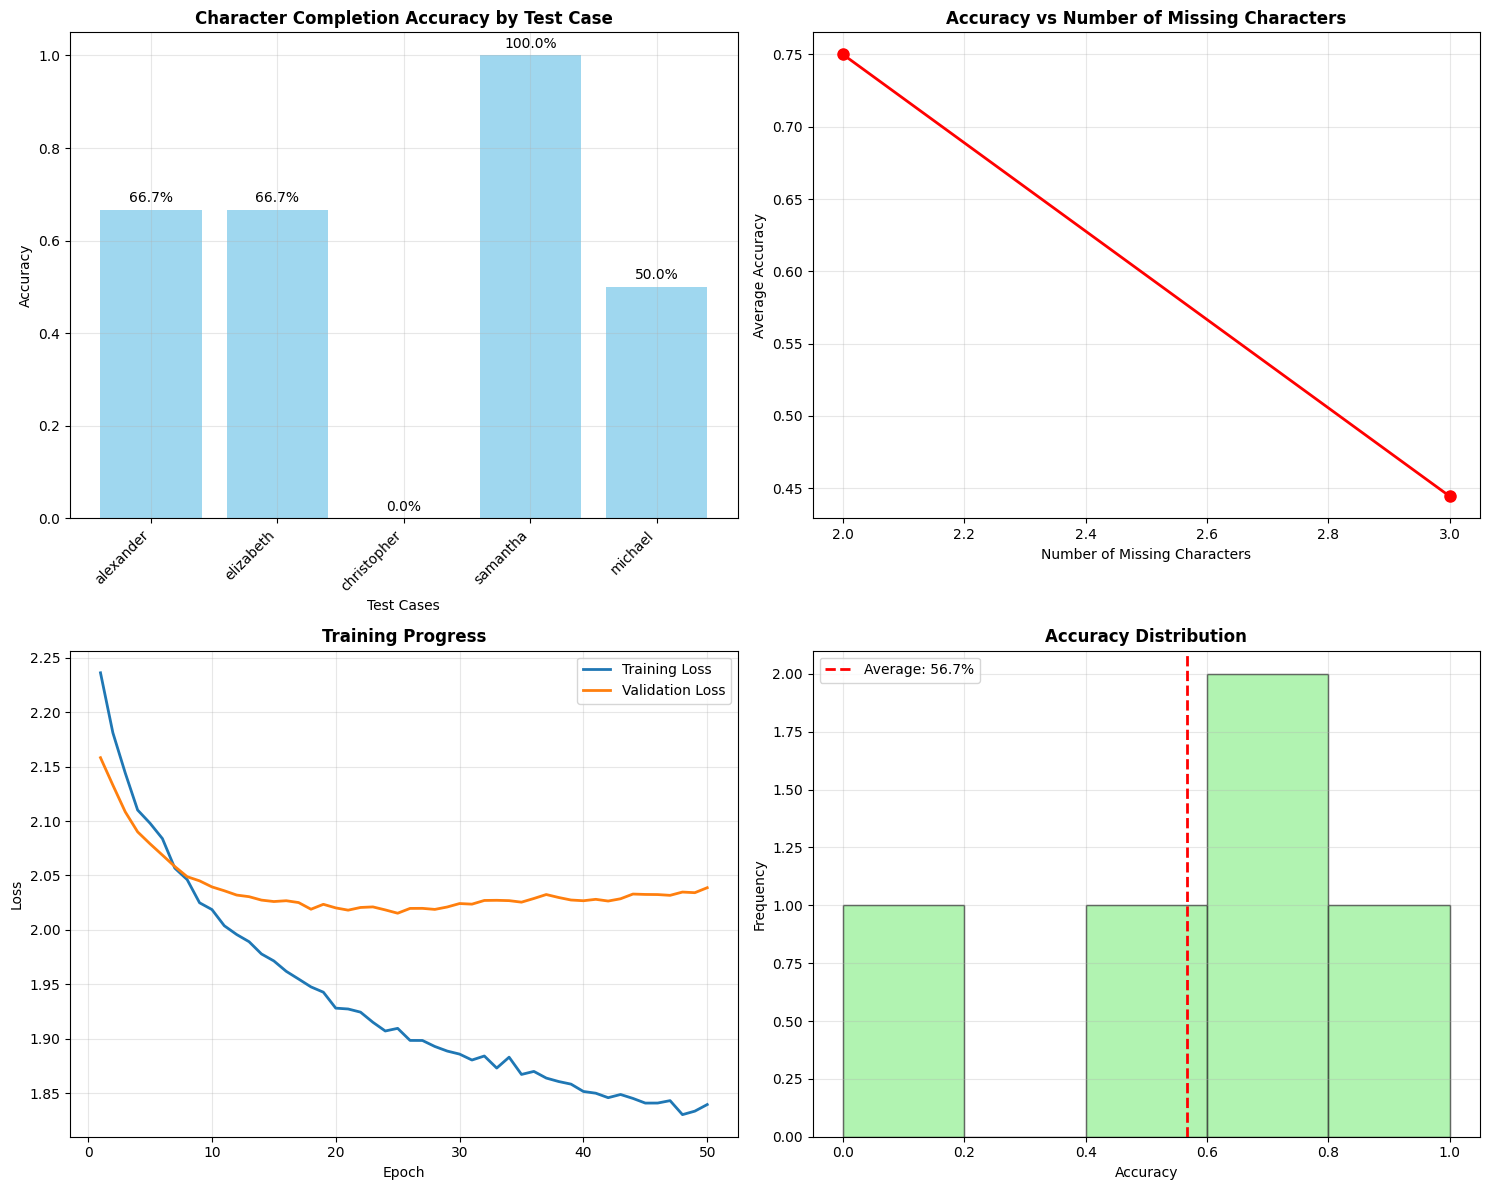

BIDIRECTIONAL MODEL PERFORMANCE REPORT
Overall Accuracy: 56.7%
Total Test Cases: 5

Performance by Missing Character Count:
  2 missing chars: 75.0% (from 2 cases)
  3 missing chars: 44.4% (from 3 cases)

Individual Test Results:
  1. alexander → allxander (66.7%)
  2. elizabeth → elizebeth (66.7%)
  3. christopher → shrnstopfer (0.0%)
  4. samantha → samantha (100.0%)
  5. michael → micheel (50.0%)


In [29]:
def generate_bidirectional_report():
    """生成bidirectional模型的综合性能报告"""

    total_tests = len(test_results)
    total_accuracy = sum(result['accuracy'] for result in test_results) / total_tests

    accuracy_by_missing_count = {}
    for result in test_results:
        missing_count = len(result['missing_positions'])
        if missing_count not in accuracy_by_missing_count:
            accuracy_by_missing_count[missing_count] = []
        accuracy_by_missing_count[missing_count].append(result['accuracy'])

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    test_names = [result['original'] for result in test_results]
    accuracies = [result['accuracy'] for result in test_results]

    bars = axes[0, 0].bar(range(len(test_names)), accuracies, color='skyblue', alpha=0.8)
    axes[0, 0].set_title('Character Completion Accuracy by Test Case', fontweight='bold')
    axes[0, 0].set_xlabel('Test Cases')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].set_xticks(range(len(test_names)))
    axes[0, 0].set_xticklabels(test_names, rotation=45, ha='right')
    axes[0, 0].grid(True, alpha=0.3)

    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{acc:.1%}', ha='center', va='bottom')

    missing_counts = sorted(accuracy_by_missing_count.keys())
    avg_accuracies = [np.mean(accuracy_by_missing_count[count]) for count in missing_counts]

    axes[0, 1].plot(missing_counts, avg_accuracies, 'ro-', linewidth=2, markersize=8)
    axes[0, 1].set_title('Accuracy vs Number of Missing Characters', fontweight='bold')
    axes[0, 1].set_xlabel('Number of Missing Characters')
    axes[0, 1].set_ylabel('Average Accuracy')
    axes[0, 1].grid(True, alpha=0.3)

    epochs = range(1, len(bi_train_losses) + 1)
    axes[1, 0].plot(epochs, bi_train_losses, label='Training Loss', linewidth=2)
    axes[1, 0].plot(epochs, bi_val_losses, label='Validation Loss', linewidth=2)
    axes[1, 0].set_title('Training Progress', fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].hist(accuracies, bins=5, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[1, 1].axvline(total_accuracy, color='red', linestyle='--', linewidth=2,
                       label=f'Average: {total_accuracy:.1%}')
    axes[1, 1].set_title('Accuracy Distribution', fontweight='bold')
    axes[1, 1].set_xlabel('Accuracy')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{RESULT_SAVE_PATH}/bidirectional_performance_report.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("BIDIRECTIONAL MODEL PERFORMANCE REPORT")
    print("=" * 60)
    print(f"Overall Accuracy: {total_accuracy:.1%}")
    print(f"Total Test Cases: {total_tests}")
    print()

    print("Performance by Missing Character Count:")
    for count in sorted(accuracy_by_missing_count.keys()):
        avg_acc = np.mean(accuracy_by_missing_count[count])
        case_count = len(accuracy_by_missing_count[count])
        print(f"  {count} missing chars: {avg_acc:.1%} (from {case_count} cases)")

    print()
    print("Individual Test Results:")
    for i, result in enumerate(test_results):
        print(f"  {i+1}. {result['original']} → {result['predicted']} ({result['accuracy']:.1%})")

    report_data = {
        'overall_accuracy': total_accuracy,
        'test_results': test_results,
        'accuracy_by_missing_count': {str(k): v for k, v in accuracy_by_missing_count.items()},
        'training_history': {
            'train_losses': bi_train_losses,
            'val_losses': bi_val_losses,
            'train_accuracies': bi_train_accuracies,
            'val_accuracies': bi_val_accuracies
        }
    }

    with open(f"{RESULT_SAVE_PATH}/bidirectional_report.json", 'w') as f:
        json.dump(report_data, f, indent=2)

    return report_data


bidirectional_report = generate_bidirectional_report()

In [30]:
def save_bidirectional_model_complete():
    """保存双向模型的完整信息"""

    complete_bi_model_info = {
        'model_state_dict': bidirectional_model.state_dict(),
        'model_config': {
            'vocab_size': processor.vocab_size,
            'embedding_dim': embedding_dim,
            'hidden_dim': hidden_dim // 2,
            'num_layers': num_layers,
            'dropout': dropout,
            'bidirectional': True
        },
        'training_config': {
            'num_epochs': len(bi_train_losses),
            'batch_size': 32,
            'learning_rate': 0.001,
            'mask_ratio': 0.3
        },
        'vocabulary': {
            'char_to_idx': char_to_idx,
            'idx_to_char': idx_to_char,
            'vocab_size': processor.vocab_size,
            'max_length': processor.max_length
        },
        'training_history': {
            'train_losses': bi_train_losses,
            'val_losses': bi_val_losses,
            'train_accuracies': bi_train_accuracies,
            'val_accuracies': bi_val_accuracies
        },
        'test_results': test_results,
        'performance_metrics': {
            'overall_accuracy': bidirectional_report['overall_accuracy'],
            'test_case_count': len(test_results)
        }
    }

    torch.save(complete_bi_model_info, f"{MODEL_SAVE_PATH}/complete_bidirectional_model.pth")

    print("Bidirectional model training and evaluation completed!")
    print(f"Model saved to: {MODEL_SAVE_PATH}/complete_bidirectional_model.pth")
    print(f"Visualizations saved to: {RESULT_SAVE_PATH}/")
    print(f"Overall character completion accuracy: {bidirectional_report['overall_accuracy']:.1%}")


save_bidirectional_model_complete()

Bidirectional model training and evaluation completed!
Model saved to: ../model/complete_bidirectional_model.pth
Visualizations saved to: ../result/
Overall character completion accuracy: 56.7%


### Bidirectional LSTM 实验总结


In [31]:
print(f"Model Architecture: Bidirectional LSTM with {hidden_dim//2}x2 hidden units")
print(f"Training Epochs: {len(bi_train_losses)}")
print(f"Final Training Accuracy: {bi_train_accuracies[-1]:.1%}")
print(f"Final Validation Accuracy: {bi_val_accuracies[-1]:.1%}")
print(f"Character Completion Accuracy: {bidirectional_report['overall_accuracy']:.1%}")
print(f"Test Cases Evaluated: {len(test_results)}")
print(f"Visualizations Generated: {len(test_results[:3])} completion processes")

Model Architecture: Bidirectional LSTM with 64x2 hidden units
Training Epochs: 50
Final Training Accuracy: 40.5%
Final Validation Accuracy: 35.4%
Character Completion Accuracy: 56.7%
Test Cases Evaluated: 5
Visualizations Generated: 3 completion processes
